In [1]:
import sys
import os
import jax
import jax.numpy as np
import amigo
import ehtplot
import scienceplots
import cmasher
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from dLux import utils as dlu
import zodiax as zdx
from zodiax.optimisation import sgd, adam
import dorito

# Basic jax import
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", True)
        
# Plotting set up
%matplotlib inline
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

plt.style.use(["science", "bright", "no-latex"])

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]
inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

In [2]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana1/snert/max/data/amigo_files/"
else:
    cache = "/Volumes/morgana1/snert/max/data/amigo_files/"
fisher_cache = os.path.join(cache, "fishers/")
model_cache = os.path.join(cache, "models/")
output_path = os.path.join(cache, "outputs/ss1/")
K_path = os.path.join(cache, "K/")

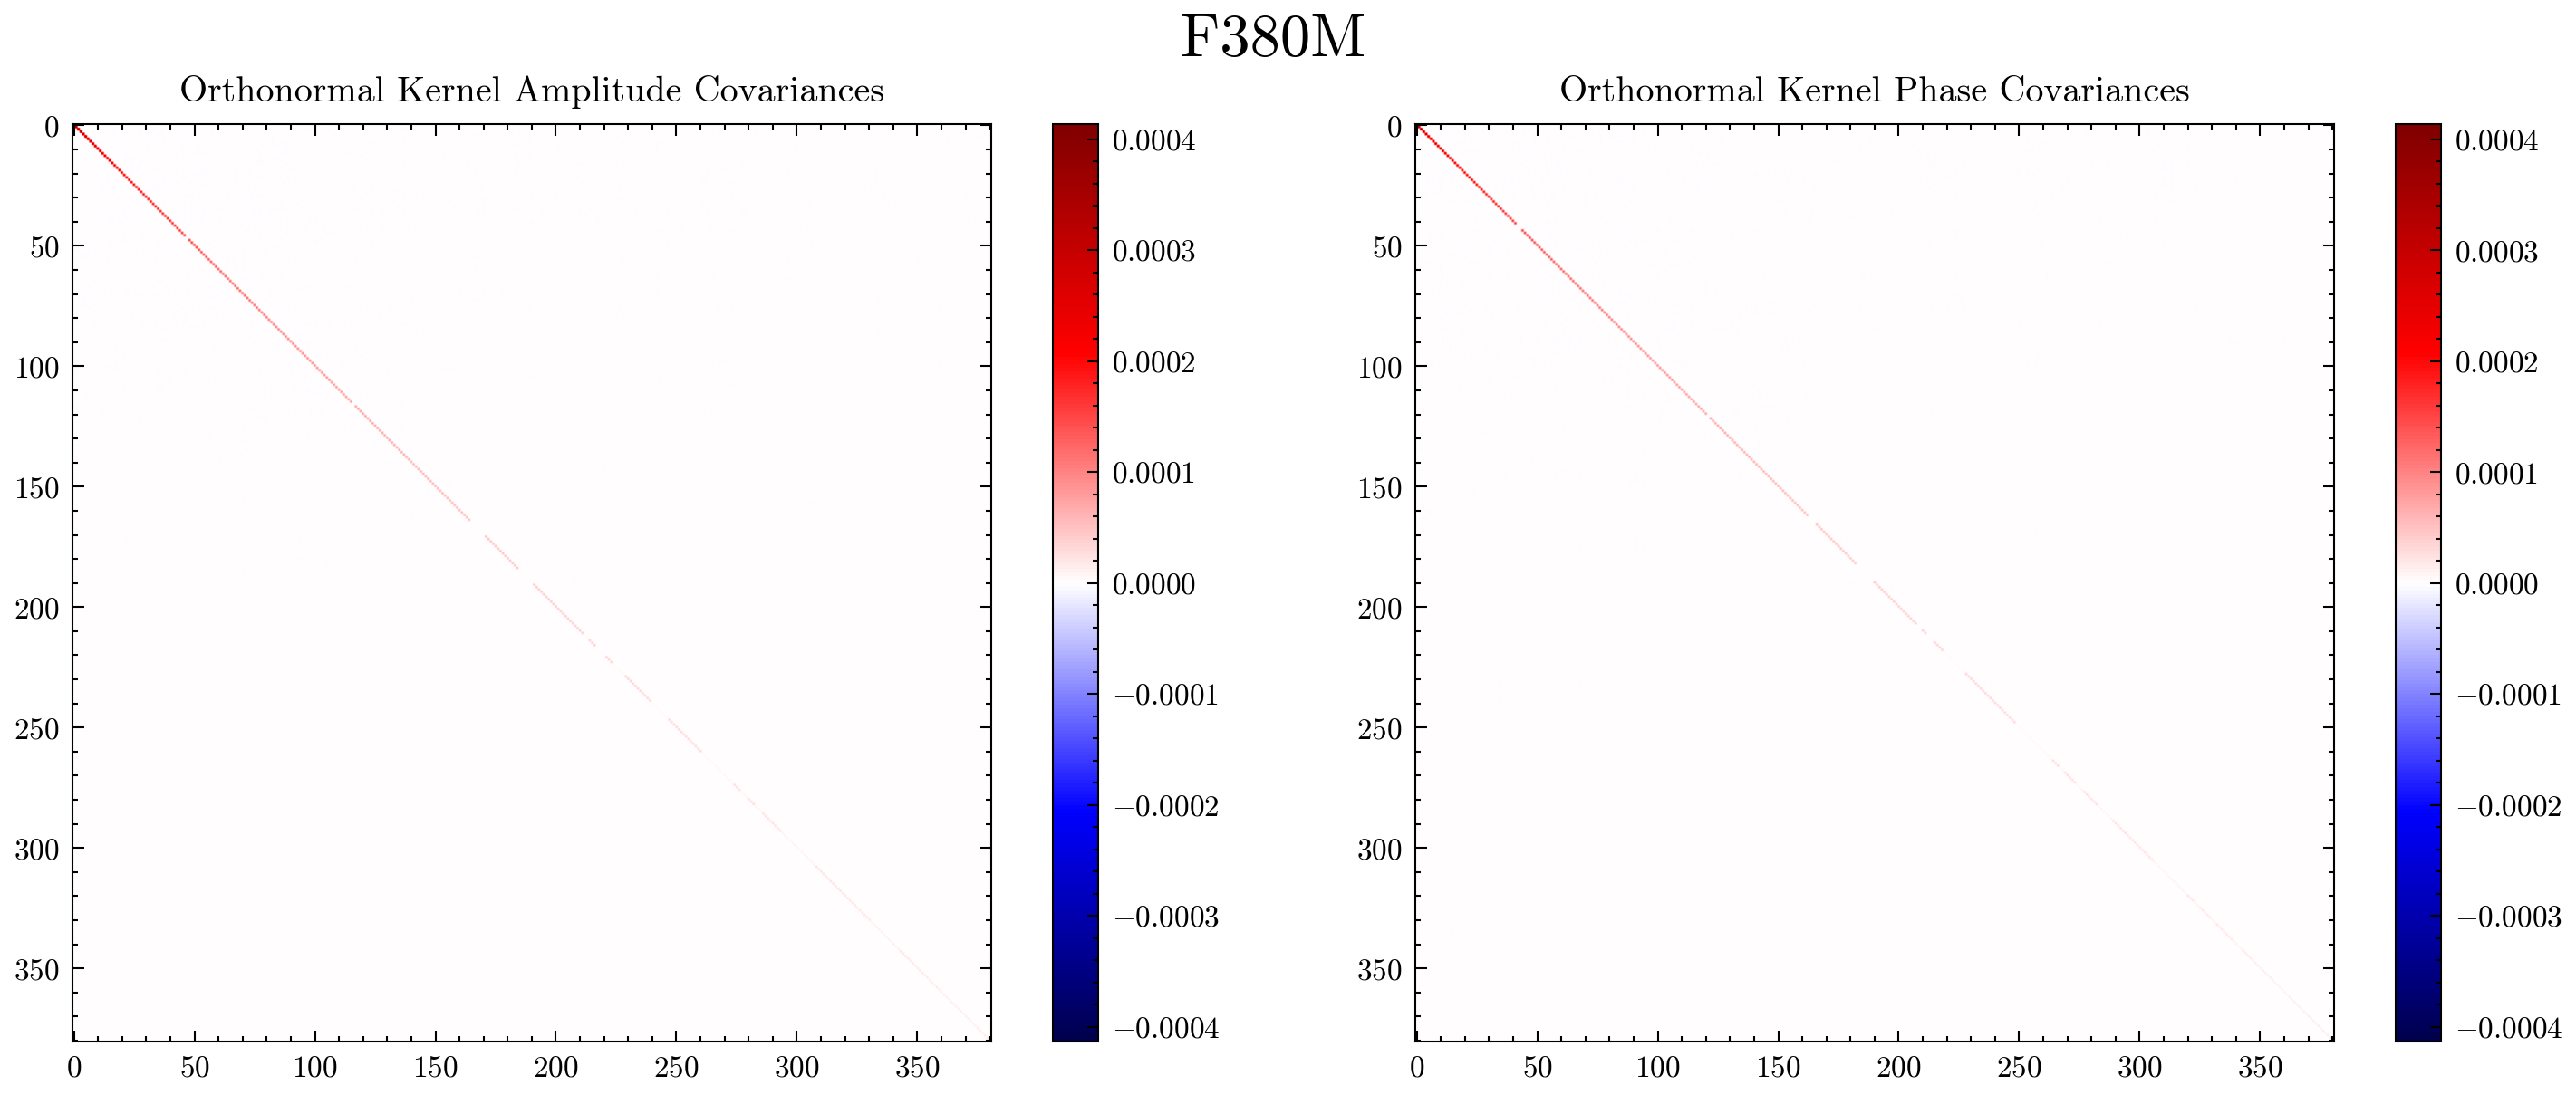

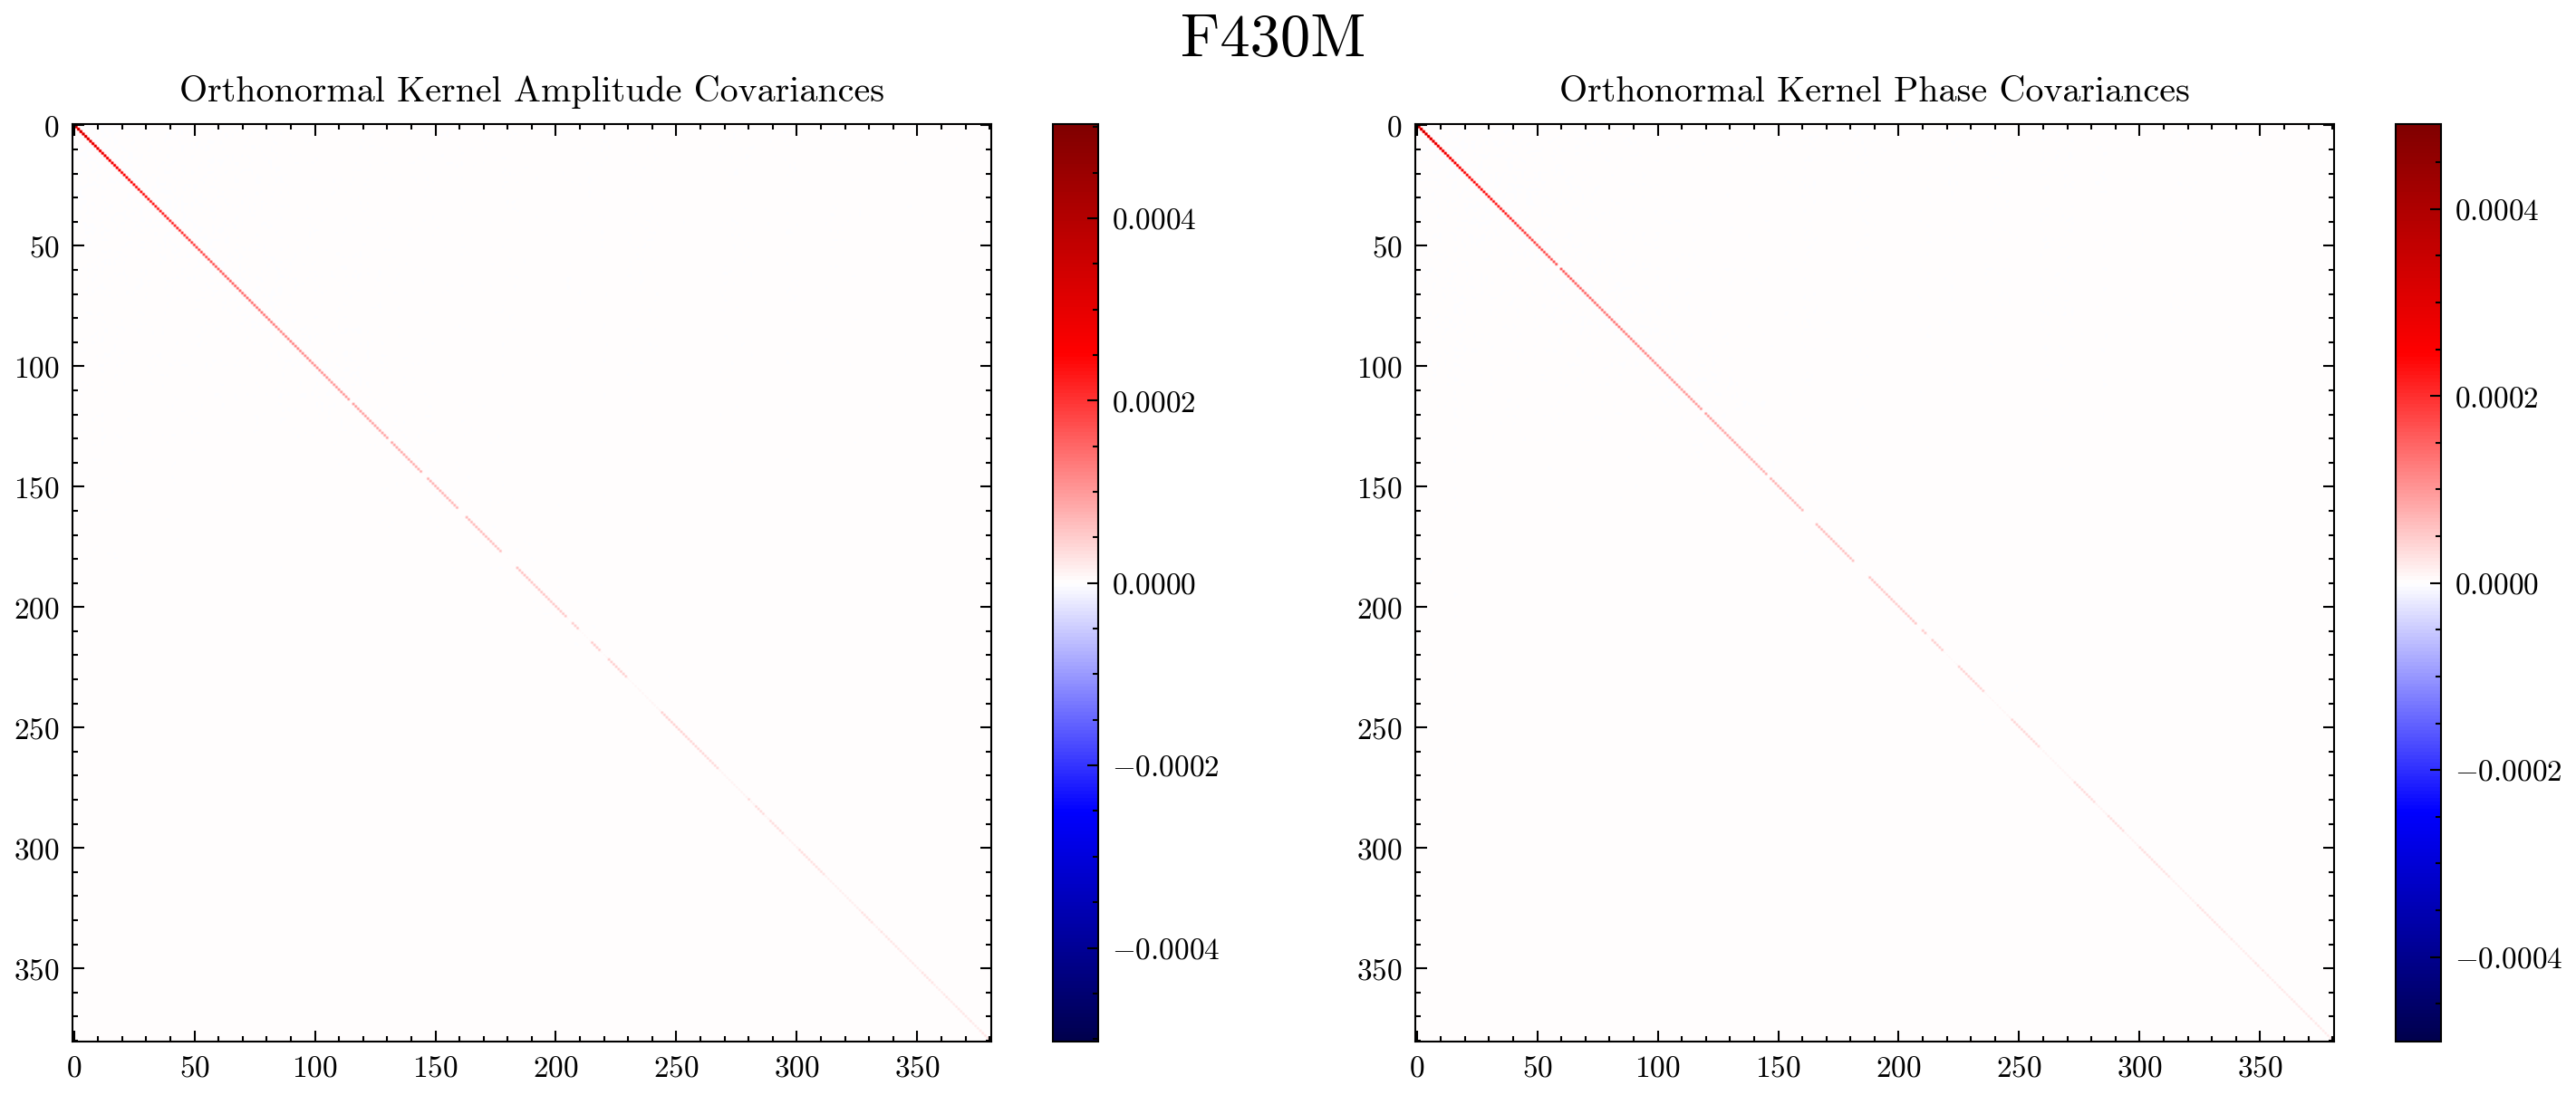

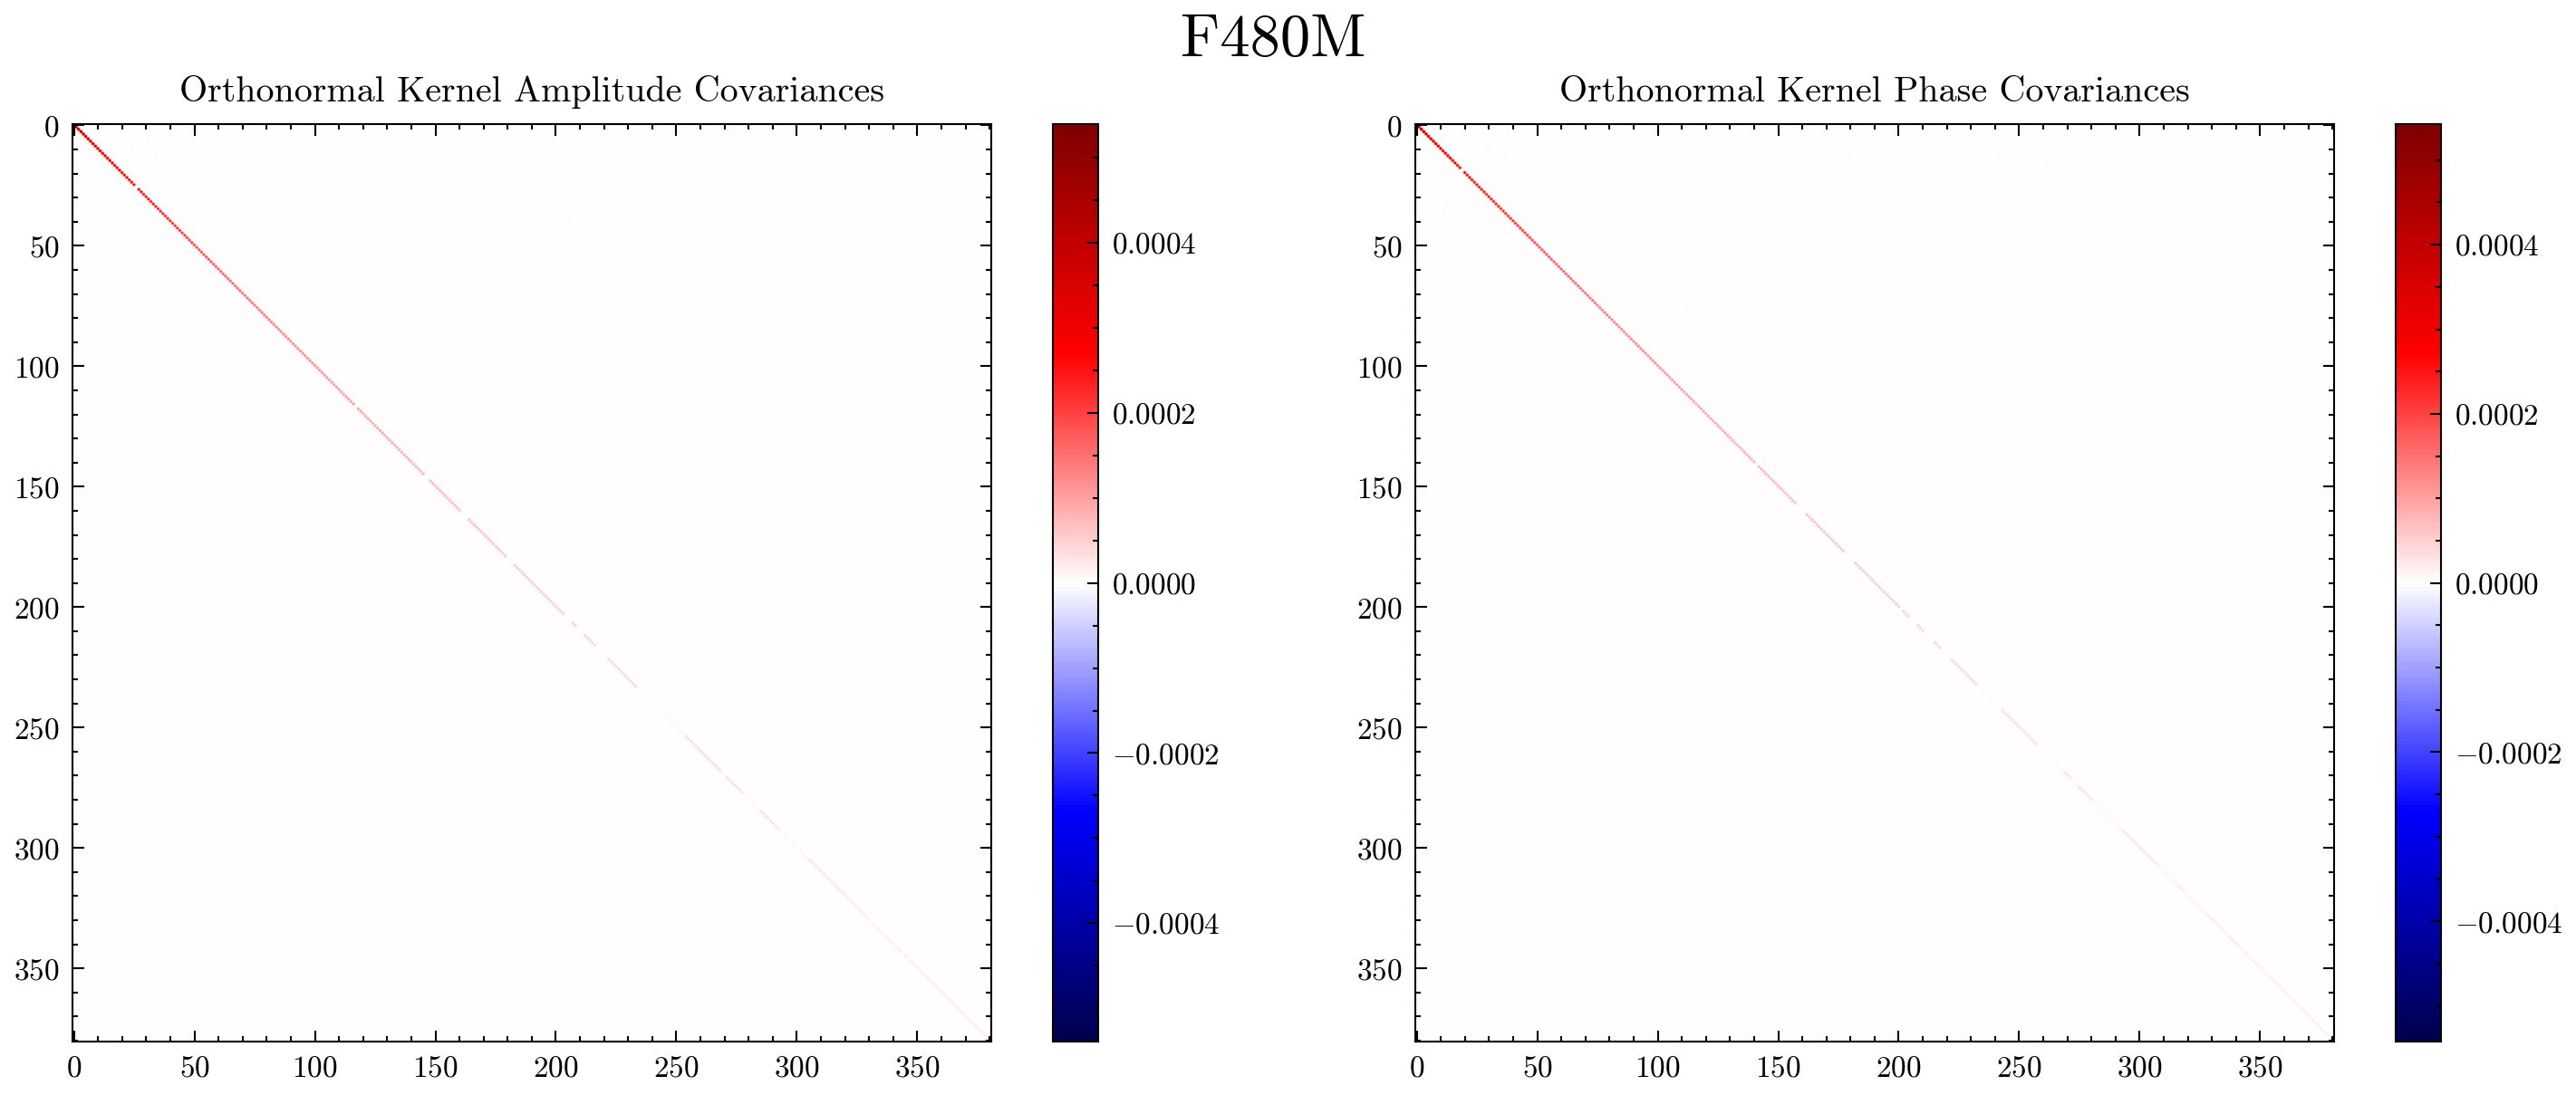

In [3]:
filters = ["F380M", "F430M", "F480M"]

cal_vis_outputs = {}
for filt in filters:
    cal_vis = np.load(
        f"/media/morgana1/snert/max/data/amigo_files/outputs/ss1/system_1_{filt}.npy",
        allow_pickle=True,
    ).item()

    vis = cal_vis["K_vis"]
    phi = cal_vis["K_phi"]
    vis_cov = cal_vis["K_vis_cov"]
    phi_cov = cal_vis["K_phi_cov"]

    vis_vals, vis_vecs = np.linalg.eig(vis_cov)
    phi_vals, phi_vecs = np.linalg.eig(phi_cov)

    vis_vals, vis_vecs = vis_vals.real, vis_vecs.real.T
    phi_vals, phi_vecs = phi_vals.real, phi_vecs.real.T

    new_vis_cov = np.dot(vis_vecs, np.dot(vis_cov, np.linalg.inv(vis_vecs)))
    new_phi_cov = np.dot(phi_vecs, np.dot(phi_cov, np.linalg.inv(phi_vecs)))

    new_vis = np.dot(vis_vecs, vis)
    new_phi = np.dot(phi_vecs, phi)

    cal_vis["vis"] = new_vis
    cal_vis["phi"] = new_phi
    cal_vis["vis_cov"] = new_vis_cov
    cal_vis["phi_cov"] = new_phi_cov
    cal_vis["K_vis_proj"] = vis_vecs
    cal_vis["K_phi_proj"] = phi_vecs

    cal_vis_outputs[filt] = cal_vis

    plt.figure(figsize=(10, 4))
    plt.suptitle(filt, fontsize=16)

    v = np.nanmax(np.abs(new_vis_cov))
    plt.subplot(1, 2, 1)
    plt.title("Orthonormal Kernel Amplitude Covariances")
    plt.imshow(new_vis_cov, seismic, vmin=-v, vmax=v, origin="upper")
    plt.colorbar()

    v = np.nanmax(np.abs(new_phi_cov))
    plt.subplot(1, 2, 2)
    plt.title("Orthonormal Kernel Phase Covariances")
    plt.imshow(new_phi_cov, seismic, vmin=-v, vmax=v, origin="upper")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

In [4]:
# import equinox as eqx
# import zodiax as zdx


# class AmigoOIData(zdx.Base):
#     # Coordinates
#     u: np.ndarray
#     v: np.ndarray
#     wavel: np.ndarray
#     parang: np.ndarray

#     # Latent Kernel Visibilities
#     vis: np.ndarray
#     d_vis: np.ndarray

#     # Latent Kernel Phases
#     phi: np.ndarray
#     d_phi: np.ndarray

#     # Latent space projection matrices
#     vis_mat: np.ndarray  # Latent -> Pixel
#     phi_mat: np.ndarray  # Latent -> Pixel

#     def __init__(self, oi_data):
#         """
#         Default should have vis, phi as their _latent_ values
#         """
#         self.u = -np.array(oi_data["u"], dtype=float)
#         self.v = -np.array(oi_data["v"], dtype=float)
#         self.wavel = np.array(oi_data["wavel"], dtype=float)
#         self.parang = np.array(oi_data["parang"], dtype=float)

#         # Visibilities
#         self.vis = np.array(oi_data["vis"], dtype=float)
#         self.phi = np.array(oi_data["phi"], dtype=float)

#         # Uncertainties
#         self.d_phi = np.diag(oi_data["phi_cov"]) ** 0.5
#         self.d_vis = np.diag(oi_data["vis_cov"]) ** 0.5

#         pix_to_latent = np.linalg.pinv(np.array(oi_data["vis_mat"], dtype=float))
#         latent_to_kernel = np.array(oi_data["K_vis_mat"], dtype=float)
#         latent_to_ortho = np.array(oi_data["K_vis_proj"], dtype=float)
#         proj_mat = np.dot(pix_to_latent, latent_to_kernel.T)
#         proj_mat = np.dot(latent_to_ortho, proj_mat.T)
#         self.vis_mat = proj_mat.T

#         pix_to_latent = np.linalg.pinv(np.array(oi_data["phi_mat"], dtype=float))
#         latent_to_kernel = np.array(oi_data["K_phi_mat"], dtype=float)
#         latent_to_ortho = np.array(oi_data["K_phi_proj"], dtype=float)
#         proj_mat = np.dot(pix_to_latent, latent_to_kernel.T)
#         proj_mat = np.dot(latent_to_ortho, proj_mat.T)
#         self.phi_mat = proj_mat.T

#     def flatten_data(self):
#         """Flatten closure phases and uncertainties."""
#         vis_vec = np.concatenate([self.vis, self.phi])
#         vis_err = np.concatenate([self.d_vis, self.d_phi])
#         return vis_vec, vis_err

#     def flatten_model(self, cvis):
#         """
#         cvis: complex visibilities from model
#         Flatten model visibilities and phases.
#         """
#         # Project the visibilities to the latent
#         log_cvis = np.log(cvis)
#         log_vis, phi = log_cvis.real, log_cvis.imag

#         vis = np.dot(log_vis, self.vis_mat)
#         phi = np.dot(phi, self.phi_mat)
#         return np.concatenate([vis, phi])

#     def model(self, model_object):
#         """
#         Compute the model visibilities and phases for the given model object.
#         """
#         cvis = model_object.model(self.u, self.v, self.wavel)
#         return self.flatten_model(cvis)

#     # Overwrite this, it was a mistake from the beginning
#     def __repr__(self):
#         return eqx.Module.__repr__(self)

In [5]:
# class ResolvedOIFit(AmigoOIData):
#     """
#     Amigo OI Fit class
#     """

#     key: str
#     filter: str

#     def __init__(self, oi_data, key):
#         self.key = key
#         self.filter = key
#         super().__init__(oi_data)

#     def initialise_params(self, model, distribution):
#         params = {}

#         # centre = distribution.shape[0] // 2
#         # centre_val = distribution[centre, centre]
#         # distribution /= centre_val

#         distribution /= distribution.sum()

#         params["log_dist"] = self.get_key("log_dist"), np.log10(distribution)

#         params["base_uv"] = self.get_key("base_uv"), self.get_base_uv(
#             model, distribution.shape[0]
#         )

#         return params

#     def get_base_uv(self, model, n_pix):
#         """
#         Get the base uv for normalisation
#         """
#         ind = n_pix // 2
#         base_dist = np.zeros((n_pix, n_pix)).at[ind, ind].set(1.0)

#         # base uv for normalisation
#         base_uv = self.to_otf(model, base_dist)
#         return base_uv

#     def to_otf(self, model, distribution):

#         # distribution = np.pad(distribution, 5 * distribution.shape[0])

#         return dlu.MFT(
#             phasor=distribution + 0j,
#             wavelength=self.wavel,
#             pixel_scale_in=model.pscale_in,
#             npixels_out=model.uv_npixels,
#             pixel_scale_out=model.uv_pscale,
#         )

#     def dirty_image(self, model, npix):

#         log_vis = np.dot(self.vis, np.linalg.pinv(self.vis_mat))
#         phase = np.dot(self.phi, np.linalg.pinv(self.phi_mat))
#         vis_im, phase_im = amigo.vis_models.vis_to_im(log_vis, phase, (51, 51))

#         uv = np.exp(vis_im + 1j * phase_im)

#         return dlu.MFT(
#             phasor=uv,
#             wavelength=self.wavel,
#             pixel_scale_in=model.uv_pscale,
#             npixels_out=npix,
#             pixel_scale_out=model.pscale_in,
#             inverse=True,
#         )

#     def to_logvis(self, model, distribution):
#         """
#         Get the log visibilities
#         """
#         # Getting regular visibilities
#         uv = self.to_otf(model, distribution)

#         # Normalise the visibilities, take log and get amp and phase
#         uv /= model.params["base_uv"][self.get_key("base_uv")]
#         uv = dlu.downsample(uv, 2, mean=True)
#         vis = uv.flatten()[: uv.size // 2]
#         vis = np.log(vis)
#         return vis.real, vis.imag

#     def get_key(self, param):

#         match param:
#             case "log_dist":
#                 return self.key
#             case "base_uv":
#                 return self.key

#     def map_param(self, param):
#         """
#         The `key` argument will return only the _key_ extension of the parameter path,
#         which is required for object initialisation.
#         """

#         # Map the appropriate parameter to the correct key
#         if param in ["log_dist", "base_uv"]:
#             return f"{param}.{self.get_key(param)}"

#         # Else its global
#         return param

#     def model_sicko(self, model, distribution):

#         # Getting log visibilities
#         log_amp, phase = self.to_logvis(model, distribution)

#         # Transform to the sicko basis
#         sicko_amp = np.dot(log_amp, self.vis_mat)
#         sicko_phase = np.dot(phase, self.phi_mat)

#         return sicko_amp, sicko_phase
#         # return np.concatenate([sicko_amp, sicko_phase])
#         # return np.vstack([sicko_amp, sicko_phase])

#     def __call__(self, model):
#         """
#         Call the model with the given parameters.
#         """
#         # NOTE: Distribution must be odd number of pixels in one axis
#         distribution = 10 ** model.params["log_dist"][self.get_key("log_dist")]

#         return self.model_sicko(model, distribution=distribution)


# class ResolvedSickoModel(amigo.core_models.BaseModeller):

#     uv_npixels: int
#     uv_pscale: float
#     oversample: float
#     psf_pixel_scale: float

#     def __init__(
#         self,
#         ois: list,
#         distribution: np.ndarray,
#         uv_npixels: int,
#         uv_pscale: float,
#         oversample: float = 1.0,
#         psf_pixel_scale: float = 0.065524085,  # arcsec/pixel
#     ):

#         self.uv_npixels = uv_npixels
#         self.oversample = oversample
#         self.uv_pscale = uv_pscale
#         self.psf_pixel_scale = psf_pixel_scale

#         params = {}
#         for oi in ois:
#             param_dict = oi.initialise_params(self, distribution)
#             for param, (key, value) in param_dict.items():
#                 if param not in params.keys():
#                     params[param] = {}
#                 params[param][key] = value

#         super().__init__(params)

#     @property
#     def pscale_in(self):
#         return dlu.arcsec2rad(self.psf_pixel_scale / self.oversample)

#     def get_distribution(self, exposure):
#         """
#         Get the distribution from the exposure
#         """
#         log_dist = self.params["log_dist"][exposure.get_key("log_dist")]
#         return 10**log_dist


# def augment_phimat(oi):
#     """
#     Augment the phi matrix with the tilt vector
#     """
#     phi_mat = oi.phi_mat
#     u, v = oi.u, oi.v

#     # Tip vector (ramp in u)
#     mu = u / np.linalg.norm(u)
#     mv = v / np.linalg.norm(v)

#     aug_phimat = np.concatenate(
#         [phi_mat, mu.reshape(-1, 1), mv.reshape(-1, 1)], axis=1
#     )  # shape: (n_sickos + 2, n_frequels)

#     return oi.set("phi_mat", aug_phimat)


# def fake_a_sicko(oi, err):

#     phi = np.concatenate([oi.phi] + 2 * [np.array([0.0])])
#     d_phi = np.concatenate([oi.d_phi] + 2 * [np.array([err])])

#     return oi.set(["phi", "d_phi"], [phi, d_phi])


# def center_phase(oi, err=1e-3):
#     oi = augment_phimat(oi)
#     oi = fake_a_sicko(oi, err)
#     return oi

In [6]:
# def vis_to_im(log_amps, phases, shape):
#     # Conjugate the amplitudes and phases
#     log_amps = np.concatenate([log_amps, np.array([0.0]), log_amps[::-1]], axis=0)
#     phases = np.concatenate([phases, np.array([0.0]), -phases[::-1]], axis=0)
#     return log_amps.reshape(shape), phases.reshape(shape)


# amp_im, phase_im = vis_to_im(amp, phase, (51, 51))

# plt.figure(figsize=(10, 4))
# plt.subplot(1, 2, 1)
# plt.title("Amplitude")
# plt.imshow(amp_im.at[25, 25].set(np.nan))
# plt.colorbar()
# plt.subplot(1, 2, 2)
# plt.title("Phase")
# plt.imshow(phase_im.at[25, 25].set(np.nan), "twilight")
# plt.colorbar()
# plt.show()

# plt.hist(amp)
# plt.show()
# plt.hist(phase)
# plt.show()

In [7]:
eig_mats = zdx.experimental.deserialise(K_path + "eigmats.zdx")

optics = amigo.optical_models.AMIOptics()
otf_coords = dlu.pixel_coords(51, 2 * optics.diameter)
vis_model = amigo.vis_models.LogVisModel(
    eig_mats["amplitude"],
    eig_mats["phase"],
    otf_coords,
    n_terms=400,
)

ois = [
    dorito.model_fits.ResolvedOIFit(oi_data, filt)
    for filt, oi_data in cal_vis_outputs.items()
]
# ois = [center_phase(oi) for oi in ois]

# distribution = np.zeros((41, 41)).at[20, 20].set(1.0)  # + 1e-16
# distribution = np.zeros((99, 99)).at[49, 49].set(0.99) + 1e-4
distribution = np.ones((151, 151))
# distribution = np.zeros((51, 51)).at[25, 25].set(1.0) + 1e-2

model = dorito.models.ResolvedSickoModel(
    ois,
    distribution / distribution.sum(),
    uv_npixels=2 * vis_model.otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(vis_model.otf_coords[0, 0]).mean(),
    oversample=3.0,
)

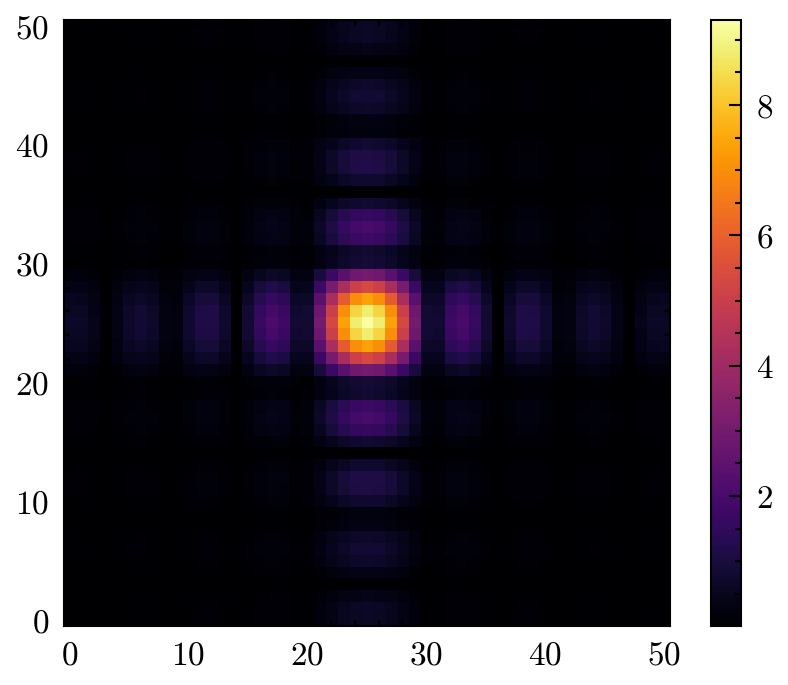

In [ ]:
dirty = ois[0].dirty_image(model, 51)

plt.imshow(dirty)
plt.colorbar()
plt.show(

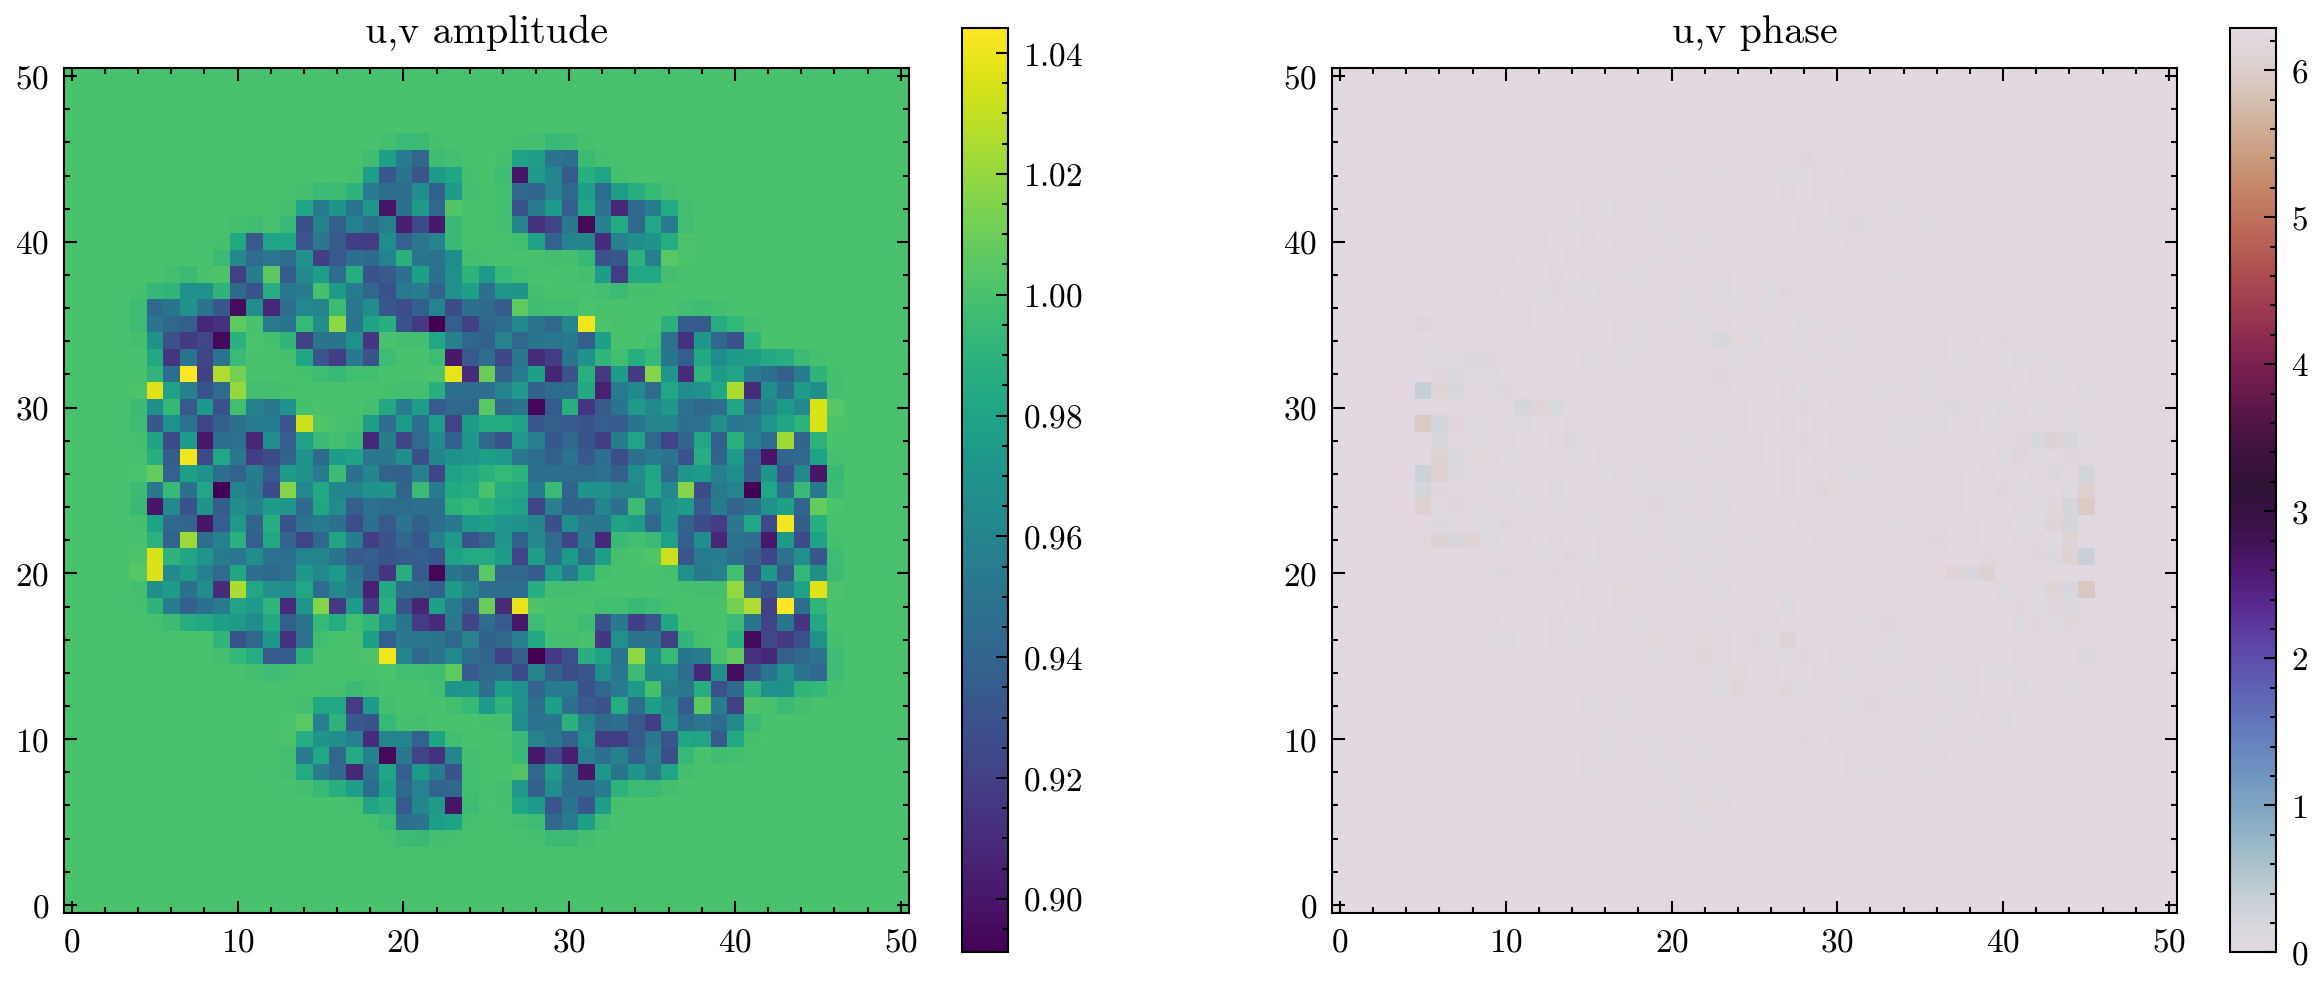

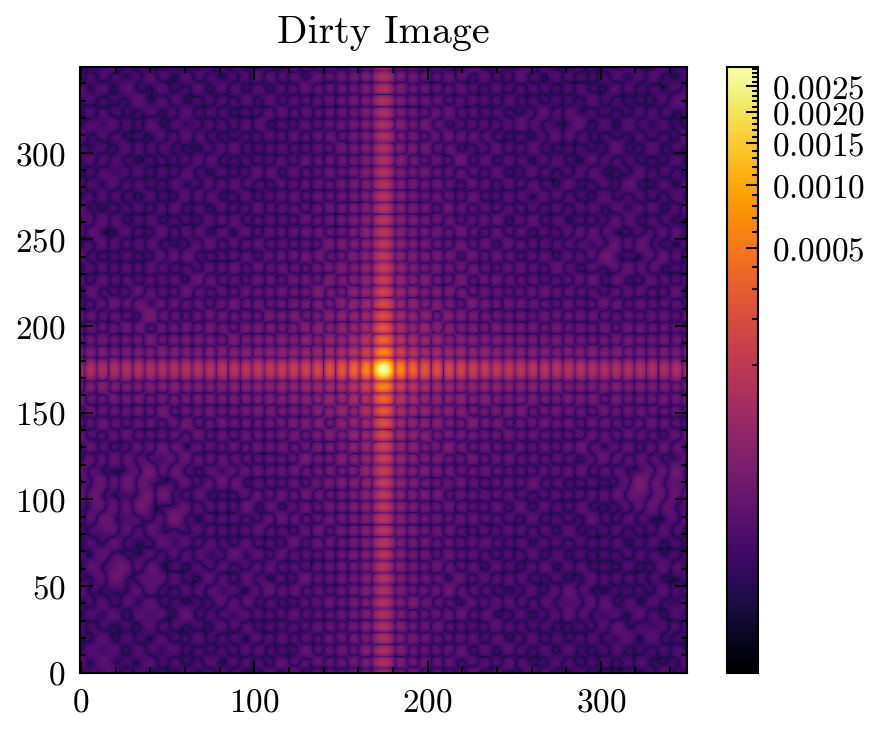

In [ ]:
# # binary = np.zeros((99, 99)).at[49, 49].set(1.0).at[60, 61].set(0.5)

# # binary /= binary.sum()
# # # distribution = np.zeros((51, 51)).at[25, 25].set(1.0) + 1e-2

# # model = ResolvedSickoModel(
# #     ois,
# #     binary / binary.sum(),
# #     uv_npixels=2 * vis_model.otf_coords.shape[-1],
# #     uv_pscale=0.5 * np.diff(vis_model.otf_coords[0, 0]).mean(),
# #     oversample=3.0,
# # )

# # plt.imshow(binary, "inferno", norm=mpl.colors.PowerNorm(0.5))
# # plt.colorbar()
# # plt.title("Simulated distribution")
# # plt.show()


# # # Getting log visibilities
# # sicko_amp, sicko_phase = oi.model_sicko(model)

# # log_vis = np.dot(sicko_amp, np.linalg.pinv(oi.vis_mat))
# # phase = np.dot(sicko_phase, np.linalg.pinv(oi.phi_mat))
# # vis_im, phase_im = amigo.vis_models.vis_to_im(log_vis, phase, (51, 51))

# # uv = vis_im + 1j * phase_im
# # uv = np.exp(uv)

# plt.figure(figsize=(10, 4))
# plt.subplot(1, 2, 1)
# plt.title("u,v amplitude")
# plt.imshow(np.abs(uv), "viridis")
# plt.colorbar()
# plt.subplot(1, 2, 2)
# plt.title("u,v phase")
# plt.imshow(np.angle(uv) % 2 * np.pi, "twilight")
# plt.colorbar()
# plt.show()


# dirty = dlu.MFT(
#     phasor=uv,
#     wavelength=oi.wavel,
#     pixel_scale_in=model.uv_pscale,
#     npixels_out=350,
#     pixel_scale_out=model.pscale_in,
#     inverse=True,
# )

# dirty = np.abs(dirty)
# dirty /= dirty.sum()

# plt.imshow(dirty, norm=mpl.colors.PowerNorm(0.2))
# plt.colorbar()
# plt.title("Dirty Image")
# plt.show()

In [1]:
model.uv_pscale, model.pscale_in

NameError: name 'model' is not defined

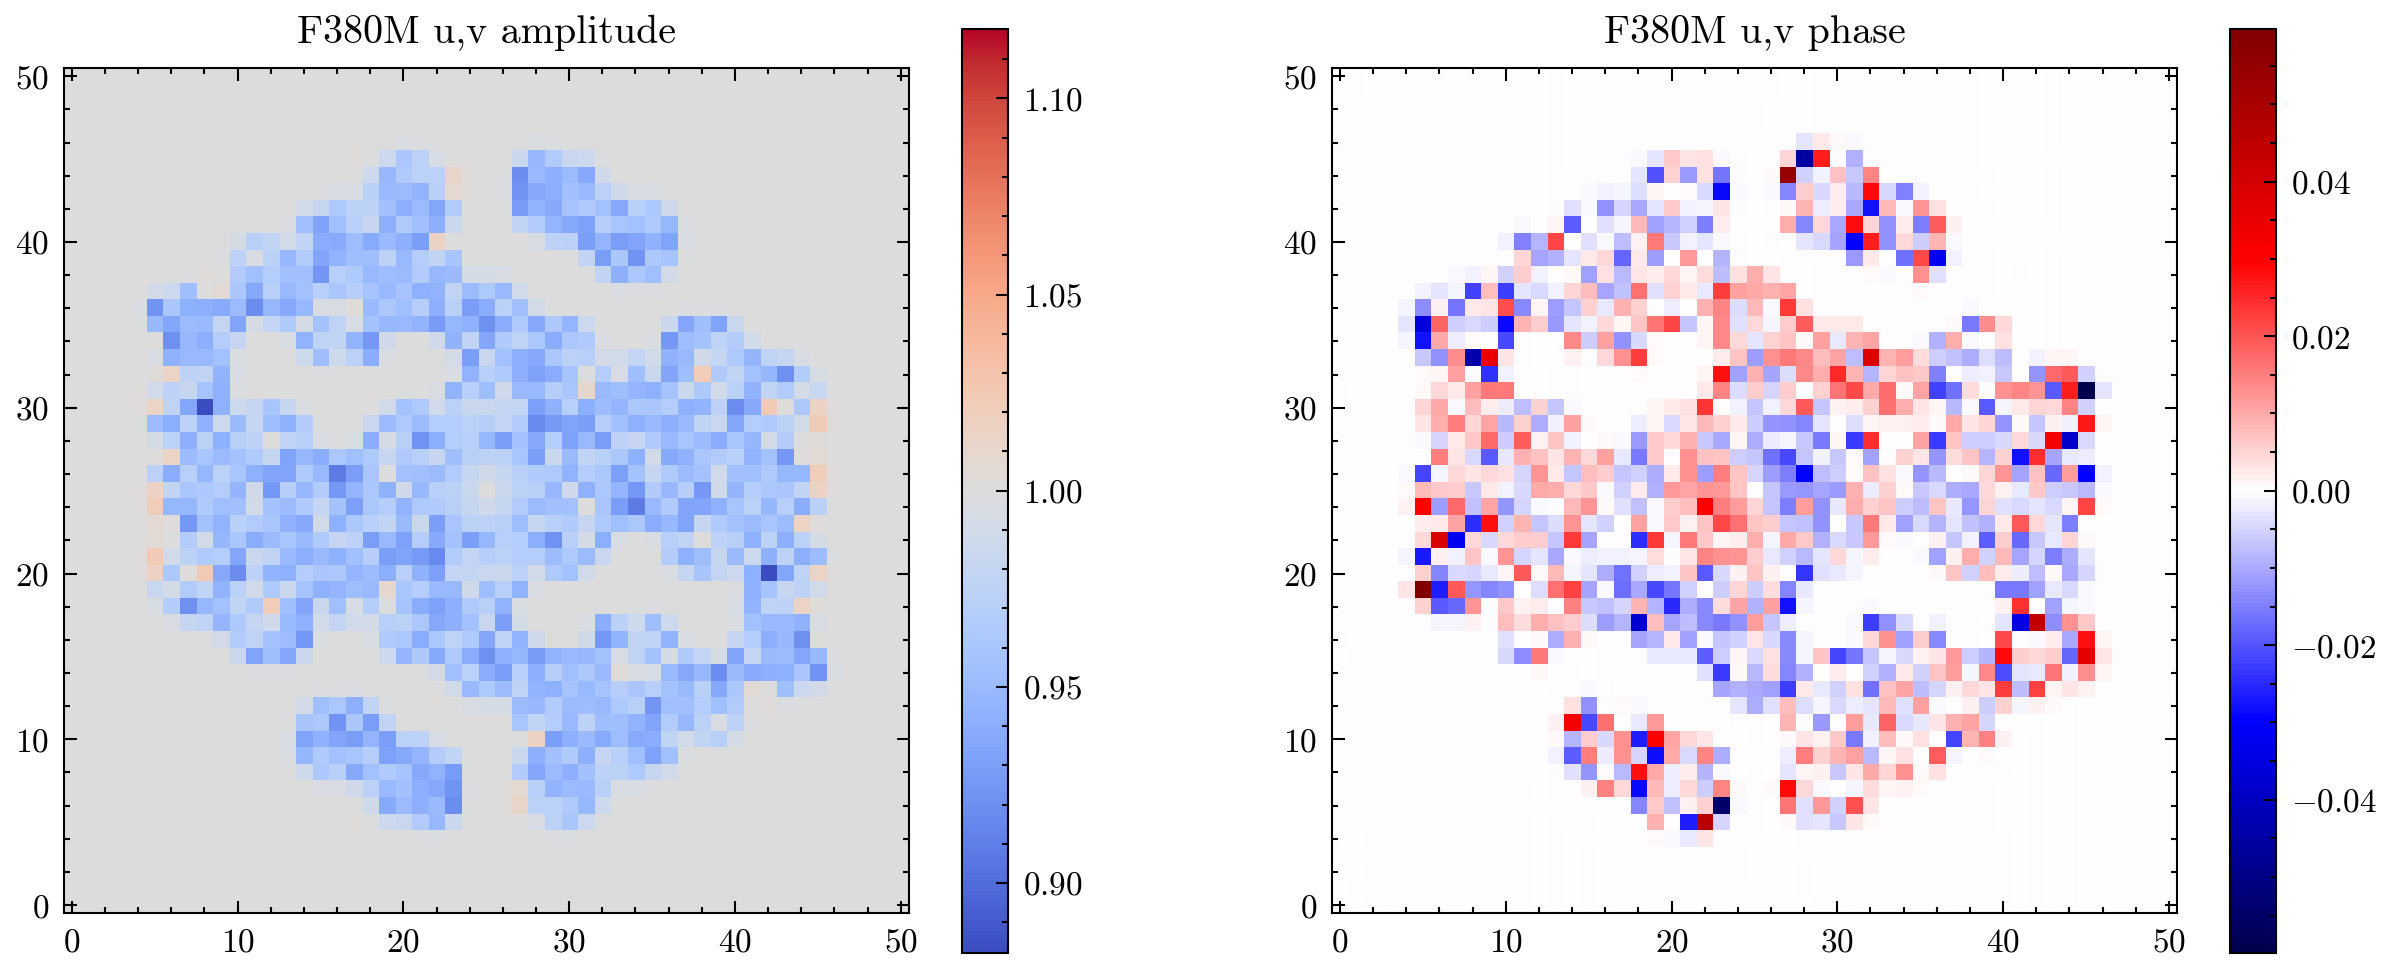

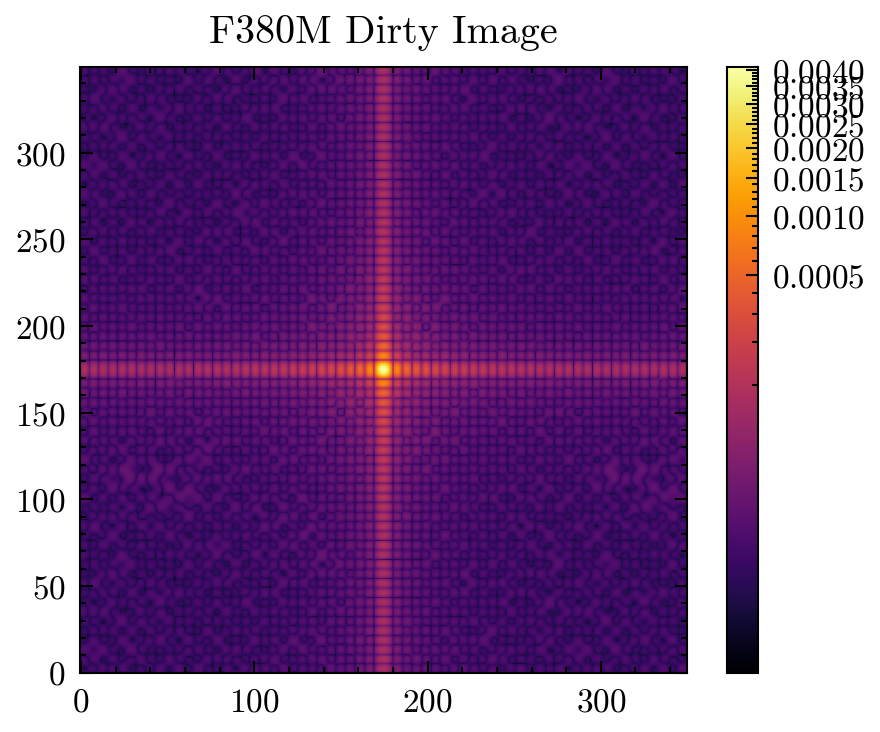

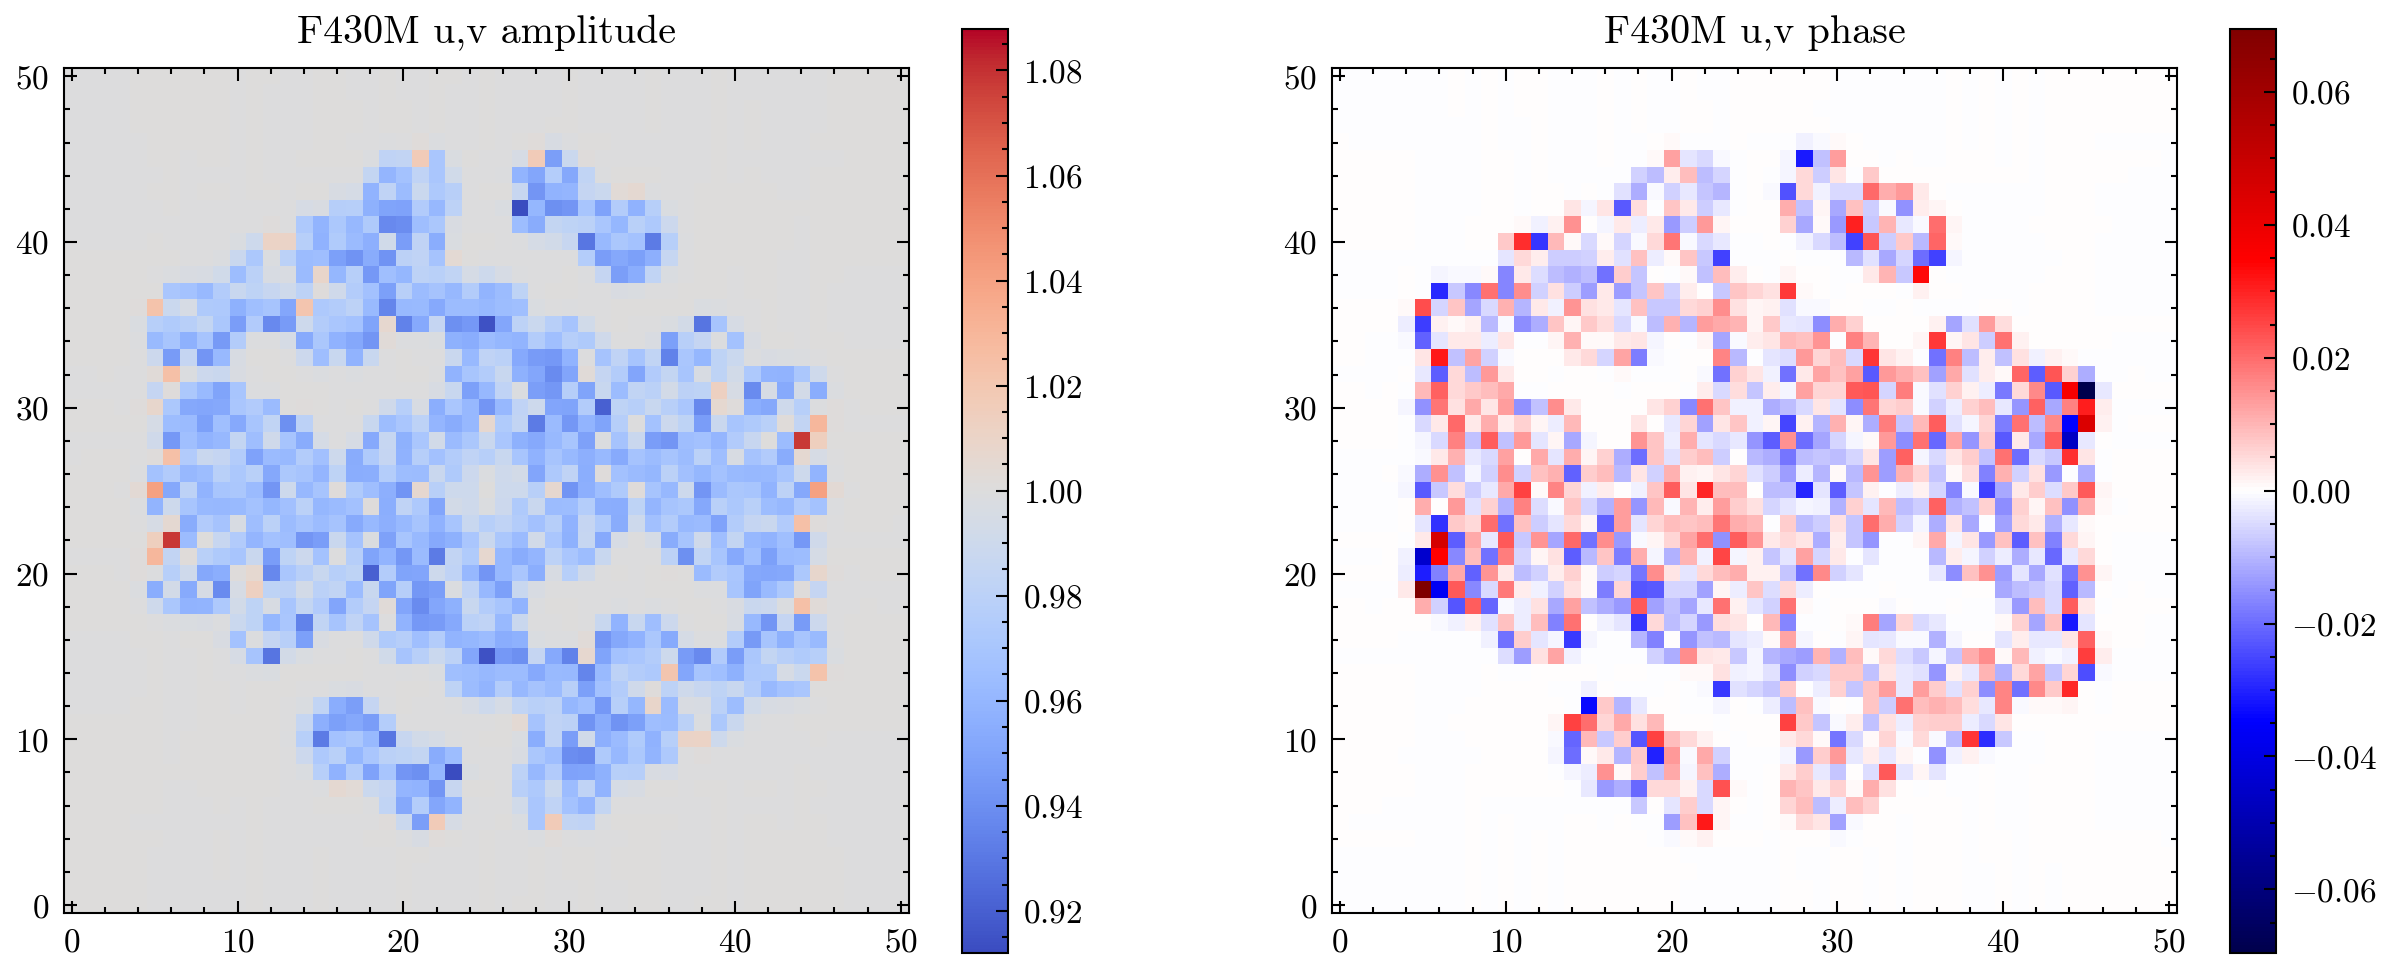

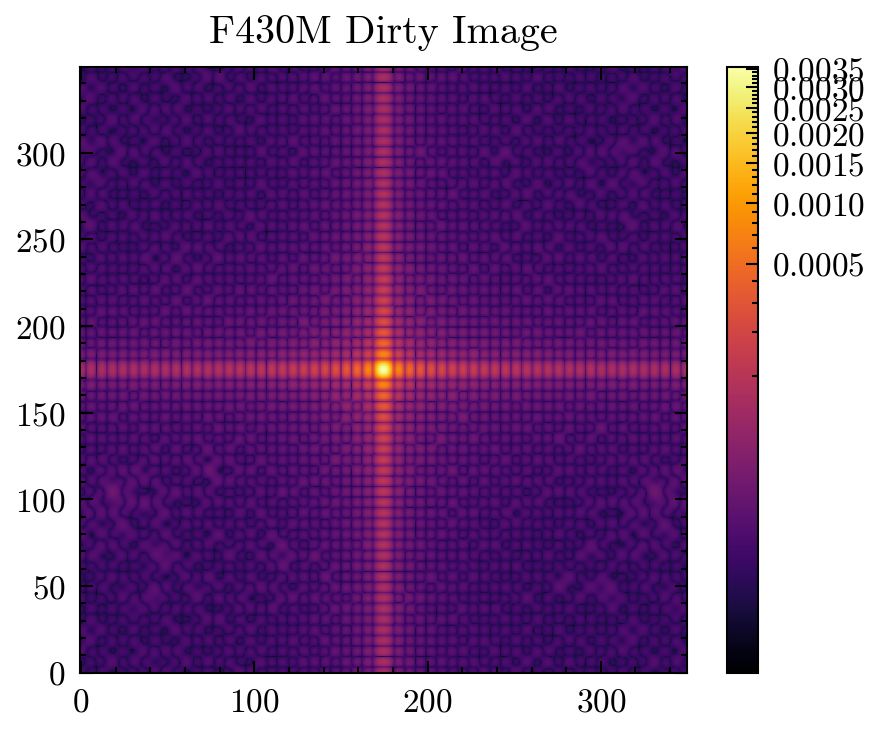

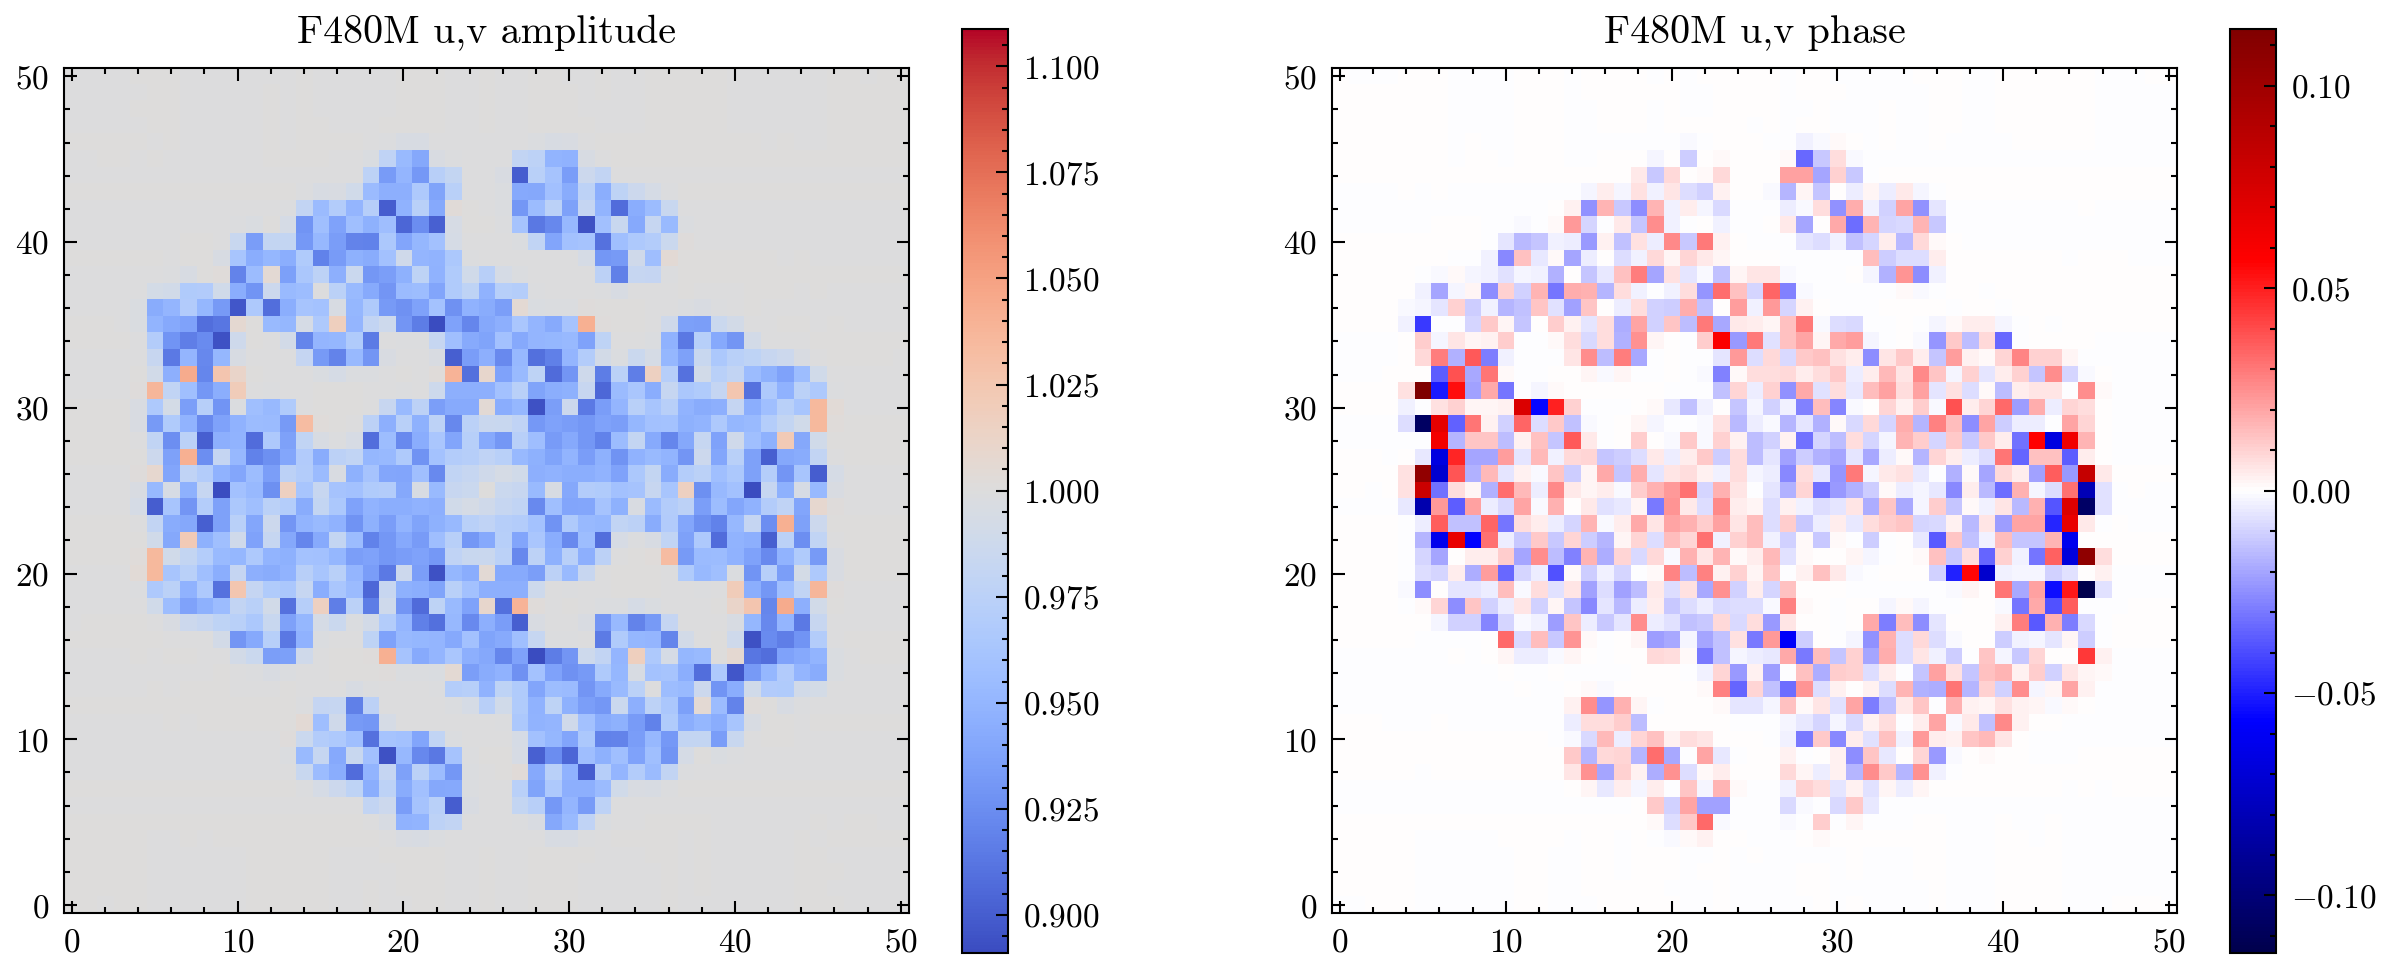

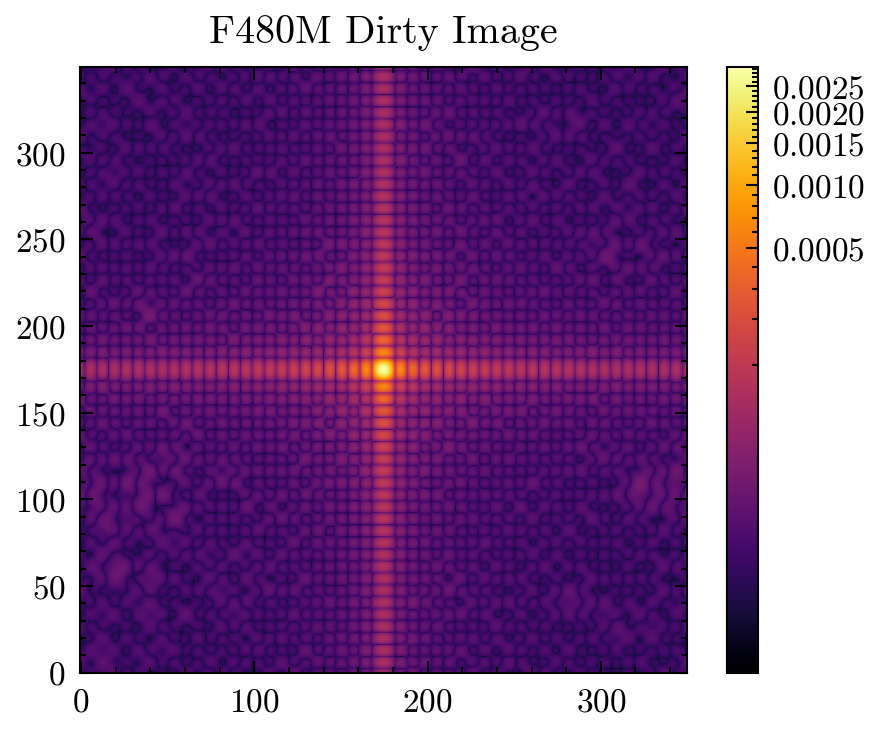

In [ ]:
for oi in ois:

    log_vis = np.dot(oi.vis, np.linalg.pinv(oi.vis_mat))
    phase = np.dot(oi.phi, np.linalg.pinv(oi.phi_mat))
    vis_im, phase_im = amigo.vis_models.vis_to_im(log_vis, phase, (51, 51))

    uv = np.exp(vis_im + 1j * phase_im)

    dirty = dlu.MFT(
        phasor=uv,
        wavelength=oi.wavel,
        pixel_scale_in=model.uv_pscale,
        npixels_out=350,
        pixel_scale_out=model.pscale_in,
        inverse=True,
    )

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.title(f"{oi.filter} u,v amplitude")
    plt.imshow(np.abs(uv), coolwarm, norm=mpl.colors.CenteredNorm(1.00))
    plt.colorbar()
    plt.subplot(1, 2, 2)
    plt.title(f"{oi.filter} u,v phase")
    plt.imshow(np.angle(uv), seismic, norm=mpl.colors.CenteredNorm())
    plt.colorbar()
    plt.show()

    dirty = np.abs(dirty)
    dirty /= dirty.sum()

    plt.imshow(dirty, norm=mpl.colors.PowerNorm(0.2))
    plt.colorbar()
    plt.title(f"{oi.filter} Dirty Image")
    plt.show()

In [121]:
# # Creating a mock point source
# dist = (
#     np.zeros((51, 51))
#     .at[25, 25]
#     .set(0.45)
#     .at[25, 27]
#     .set(0.3)
#     .at[25, 26]
#     .set(0.2)
#     .at[30, 20]
#     .set(0.05)
# )
# oi = ois[0]

# log_amp, phase = oi.to_logvis(model, dist)
# # Transform to the sicko basis
# sicko_amp = np.dot(log_amp, oi.vis_mat)
# sicko_phase = np.dot(phase, oi.phi_mat)

# amp_im, phase_im = amigo.vis_models.vis_to_im(log_amp, phase, (51, 51))

# psoi = oi.set(["vis", "phi"], [sicko_amp, sicko_phase])
# psoi = psoi.set(["d_vis", "d_phi"], 2 * [0.01 * np.ones_like(oi.d_vis)])
# ois = [psoi]

# plt.figure(figsize=(10, 4))
# plt.subplot(1, 2, 1)
# plt.title("Amplitude")
# plt.imshow(amp_im.at[25, 25].set(np.nan), inferno)
# plt.colorbar()
# plt.subplot(1, 2, 2)
# plt.title("Phase")
# plt.imshow(phase_im.at[25, 25].set(np.nan), "twilight")
# plt.colorbar()
# plt.show()

# plt.imshow(dist, "inferno")
# plt.colorbar()
# plt.title("Distribution")
# plt.show()

In [122]:
import jax.scipy as jsp
import jax.random as jr


def difflim_to_cov(model, exposure, factor):

    # calculating lambda over D
    D = 6.603464  # m
    lambda_on_D = dlu.rad2arcsec(exposure.wavel / D)

    # calculating sigma, with some factor in front of lambda on D
    sigma = dorito.misc.fwhm_to_sigma(factor * lambda_on_D)

    # return covariance matrix
    return [[sigma**2, 0], [0, sigma**2]]


def blur_distribution(array, model, exposure, extent=0.25, factor=1.0):
    cov = difflim_to_cov(model, exposure, factor)

    x = np.arange(-extent, extent, dlu.rad2arcsec(model.pscale_in))
    X, Y = np.meshgrid(x, x)
    pos = np.dstack((X, Y))

    kernel = jsp.stats.multivariate_normal.pdf(jr.PRNGKey(0), pos, np.array(cov))

    distribution = jsp.signal.convolve2d(
        array,
        kernel,
        mode="same",
        # method="fft",
    )
    return distribution / distribution.sum()


# def normalise_distribution(model_params, args):
#     params = model_params.params
#     if "log_dist" in params.keys():
#         for k, log_dist in params["log_dist"].items():
#             distribution = 10**log_dist
#             params["log_dist"][k] = np.log10(distribution / distribution.sum())

#     return model_params.set("params", params), args


def normalise_distribution(model_params, args):
    params = model_params.params

    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            distribution = 10**log_dist

            # centre = distribution.shape[0] // 2
            # norm = distribution[centre, centre]

            norm = distribution.sum()

            params["log_dist"][k] = np.log10(distribution / norm)

    return model_params.set("params", params), args


def grad_fn(model, grads, args):

    threshold = 1e-5

    params = grads.params
    if "log_dist" in params.keys():
        for k, grad in params["log_dist"].items():
            grad = np.clip(grad, threshold, threshold)
            params["log_dist"][k] = grad

    return grads.set("params", params), args


def looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.5e}")


def log_likelihood(model, oi, args={}):
    data = np.concatenate([oi.vis, oi.phi])
    err = np.concatenate([oi.d_vis, oi.d_phi])
    model_vis = np.concatenate([*oi(model)])
    # model_vis = oi(model).flatten()

    # chi2 = np.sum(jax.scipy.stats.norm.logpdf(data, loc=model_vis, scale=err))
    loglike = np.sum(((data - model_vis) / err) ** 2)

    return loglike


def apply_regularisers(model, exposure, args):
    # creating a list of regularisation functions and regularisation hyperparameters
    fn_list = [args["reg_func_dict"][reg] for reg in args["reg_dict"].keys()]
    coeff_list = list(args["reg_dict"].values())

    # evaluating the regularisation term with each for each regulariser
    priors = [
        coeff * fn(model, exposure, args) for coeff, fn in zip(coeff_list, fn_list)
    ]
    prior = np.array(priors).sum()  # summing the different regularisers

    return prior


def calc_loglike_prior(model, exposure, args):
    # this is per exposure

    # regular likelihood term
    likelihood = np.nanmean(log_likelihood(model, exposure))

    # grabbing and exponentiating log distributions
    prior = apply_regularisers(model, exposure, args)

    return likelihood, prior


def regularised_loss_fn(model, exposure, args={"reg_func_dict": {}, "reg_dict": {}}):
    # this is per exposure
    likelihood, prior = calc_loglike_prior(model, exposure, args)
    return likelihood + prior, ()
    # return likelihood + prior


def phase_centre(model, oi, args={}):

    distribution = model.get_distribution(oi)

    # Tip/Tilt vectors (ramp in u,v)
    mu = oi.u / np.linalg.norm(oi.u)
    mv = oi.v / np.linalg.norm(oi.v)

    # to log visibilities
    _log_amp, phase = oi.to_logvis(model, distribution)

    # calculating the phase centre of the distribution
    return np.hypot(np.dot(mu, phase), np.dot(mv, phase))


def centered_loss_fn(model, exposure, args, width=1e-2):
    likelihood, prior = calc_loglike_prior(model, exposure, args)

    # phase centre prior
    centre = phase_centre(model, exposure, args)
    prior += -jax.scipy.stats.norm.logpdf(centre, loc=0.0, scale=width)

    return likelihood + prior, ()


def star_reg(model, exposure, args={"prior": 0.948, "star_idx": None}):
    """
    Regulariser to penalise a central pixel from straying from a given prior value."
    """
    # grabbing index of star
    arr = model.get_distribution(exposure)
    return dorito.stats.star_reg_on_array(arr, args)


def prior_data_balance(model, exposure, args, coeff=1.0):
    likelihood, prior = calc_loglike_prior(model, exposure, args)

    return likelihood, prior / coeff


import equinox as eqx
import optimistix as optx


def BFGS_logdist(model, exposures, reg_args, max_steps=2**14):

    @eqx.filter_jit
    def fun(y, args):

        # unwrapping the args
        model, exp, reg_args = args

        # input is the log distribution
        log_dist = y

        # setting the model to the new log distribution
        params = model.params
        params["log_dist"][exp.get_key("log_dist")] = log_dist
        model = model.set("params", params)

        # calculating loss
        loss, _ = regularised_loss_fn(model, exp, reg_args)

        sum_prior = -jax.scipy.stats.norm.logpdf(
            model.get_distribution(exp).sum(), loc=1.0, scale=1e-5
        )

        return loss + sum_prior

    args_out = {}
    sols_out = {}
    for exp in exposures:

        X = model.params["log_dist"][exp.get_key("log_dist")]
        args = (model, exp, reg_args)
        args_out[exp.key] = args

        print("Initial loss:", fun(X, args))
        solver = optx.BFGS(rtol=1e-4, atol=1e-4)  # , verbose=frozenset({"loss"}))
        sol = optx.minimise(fun, solver, X, args, throw=False, max_steps=max_steps)
        sols_out[exp.key] = sol

        print("Final loss:", fun(sol.value, args))
        print(sol.stats["num_steps"], sol.state.num_accepted_steps)
        print(optx.RESULTS[sol.result])
        print()

    params = model.params
    for exp in ois:
        log_dist = sols_out[exp.key].value
        params["log_dist"][exp.get_key("log_dist")] = log_dist

    return model.set("params", params)

In [123]:
# oi = ois[0]
# # distribution = np.zeros((121, 121)).at[80, 60].set(1.0)
# distribution = result.model.get_distribution(oi)

# otf = oi.to_otf(model, distribution)

# amp_im = np.abs(otf)
# phase_im = np.angle(otf)


# plt.figure(figsize=(10, 4))
# plt.subplot(1, 2, 1)
# plt.title("Amplitude")
# plt.imshow(amp_im, inferno)
# plt.colorbar()
# plt.subplot(1, 2, 2)
# plt.title("Phase")
# plt.imshow(phase_im, "twilight")
# plt.colorbar()
# plt.show()

# plt.figure(figsize=(2, 2))
# plt.imshow(distribution, "inferno")
# # plt.colorbar()
# plt.title("Distribution")
# plt.axis("off")
# plt.show()

# log_amp, phase = oi.to_logvis(model, distribution)

# # Transform to the sicko basis
# sicko_amp = np.dot(log_amp, oi.vis_mat)
# sicko_phase = np.dot(phase, oi.phi_mat)

# print(sicko_amp[-2], sicko_phase[-2])
# print(sicko_amp[-1], sicko_phase[-1])

In [124]:
n_epoch = 5000

config = {
    # "log_dist": sgd(5e-8, 0, (500, 0.5)),
    "log_dist": sgd(1e-9, 0, (1000, 10)),
    # "log_dist": sgd(1e-9, 0, (200, 10), (500, 2)),
    # "log_dist": sgd(1e-9, 0, (50, 20), (500, 4)),
    # "log_dist": adam(1e-2, 0, (500, 2)),
    # "log_dist": sgd(5e-9, 0, (500, 2), (1000, 2)),
    # "log_dist": sgd(1e-8, 0, (10, 5), (500, 0.25), (1000, 1.5), (1300, 0.75)),
}

args = {
    "reg_func_dict": {
        "ME": dorito.stats.ME,
        "TV": dorito.stats.TV,
        "L2": dorito.stats.L2,
        "TSV": dorito.stats.TSV,
        "S": star_reg,
    },
    "reg_dict": {
        # "S": 1e10,
        # "ME": 1e5,
        # "TV": 1.0,
        # "L2": 1e-5,
        # "TSV": 5e6,
    },
    "prior": 0.97,
    "star_idx": None,
}

trainer = amigo.fitting.Trainer(
    loss_fn=regularised_loss_fn,
    # loss_fn=centered_loss_fn,
    cache=fisher_cache,
    # grad_fn=grad_fn,s
    norm_fn=normalise_distribution,
    looper_fn=looper,
)

trainer = trainer.update_fishers(
    model=model,
    exposures=[],
    parameters=[],
)

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=ois,
    args=args,
    # batches=exposures,
)

0it [00:00, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 1,523,185,051.89
Estimated run time: 0:00:31
Full Time: 0:00:53
Final Loss: 22,762.95


0.006586173810116703
(Array(22762.9454107, dtype=float64), Array(0., dtype=float64))


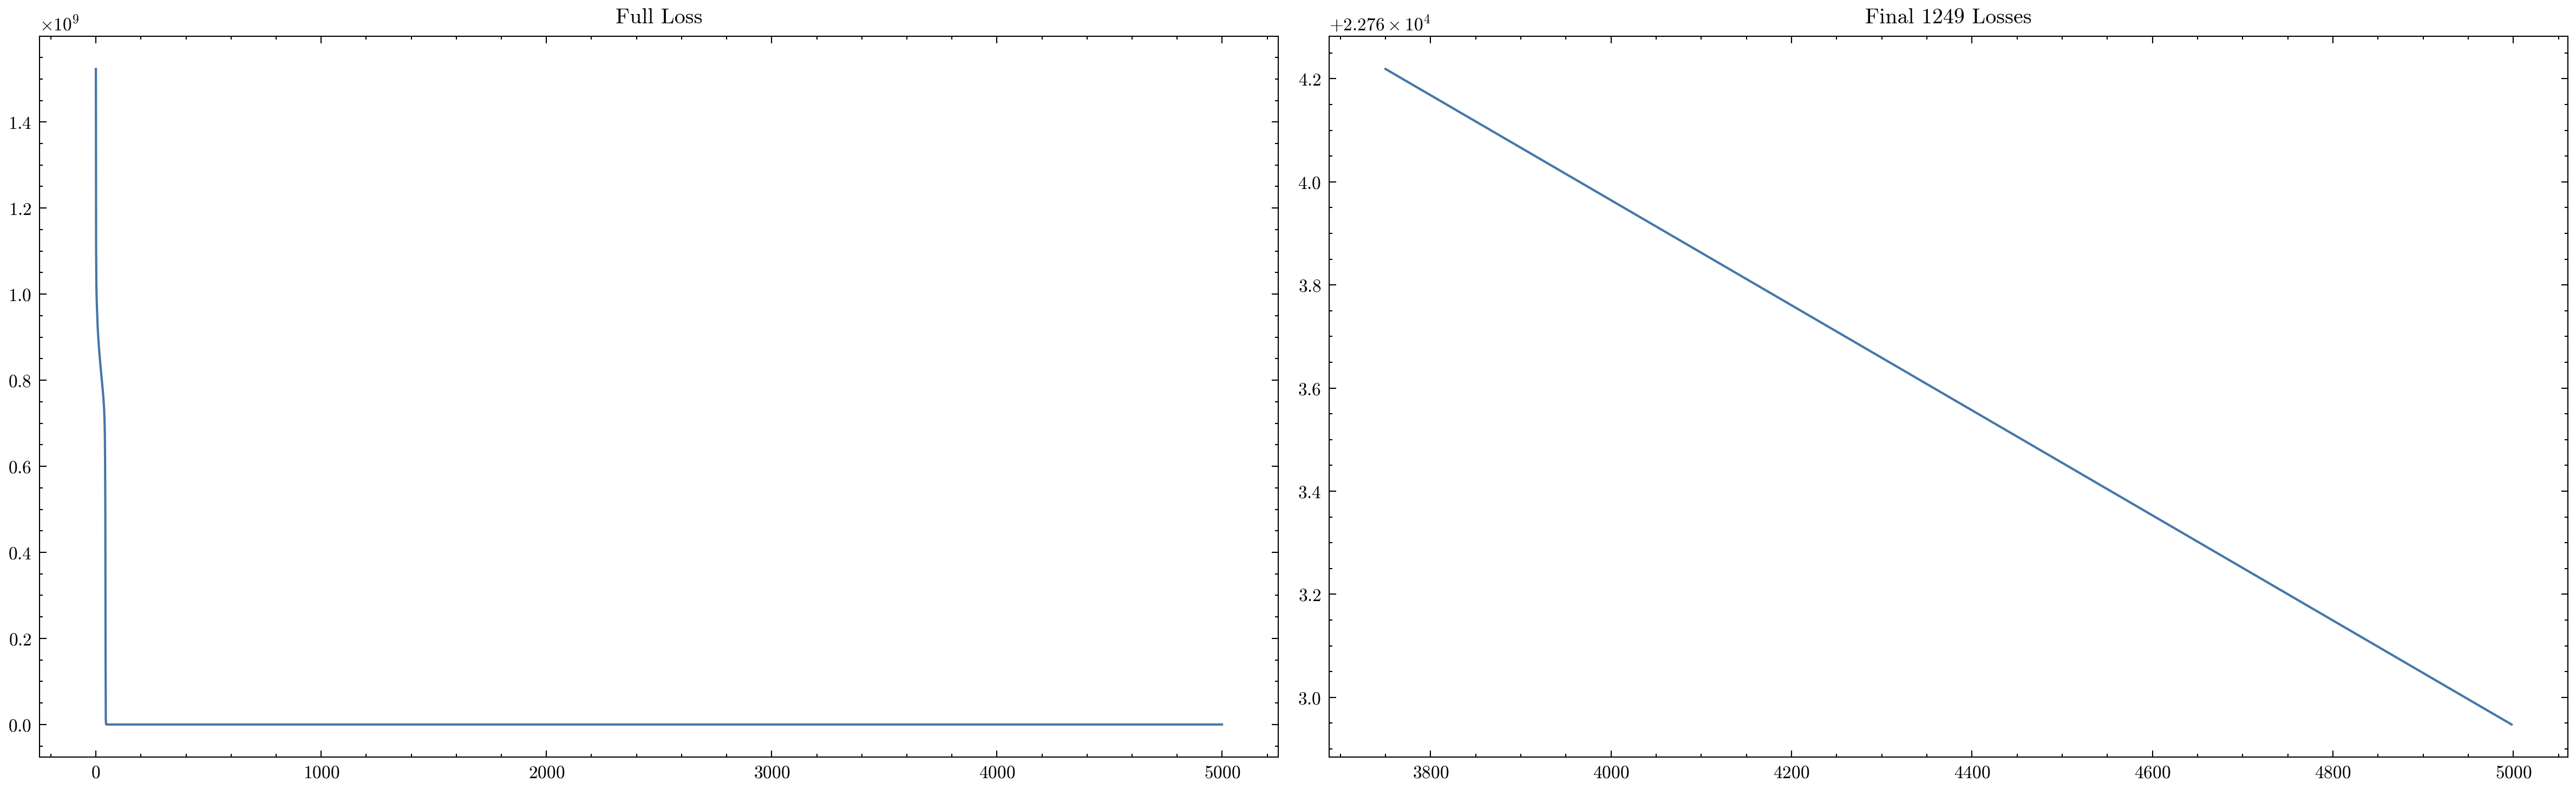

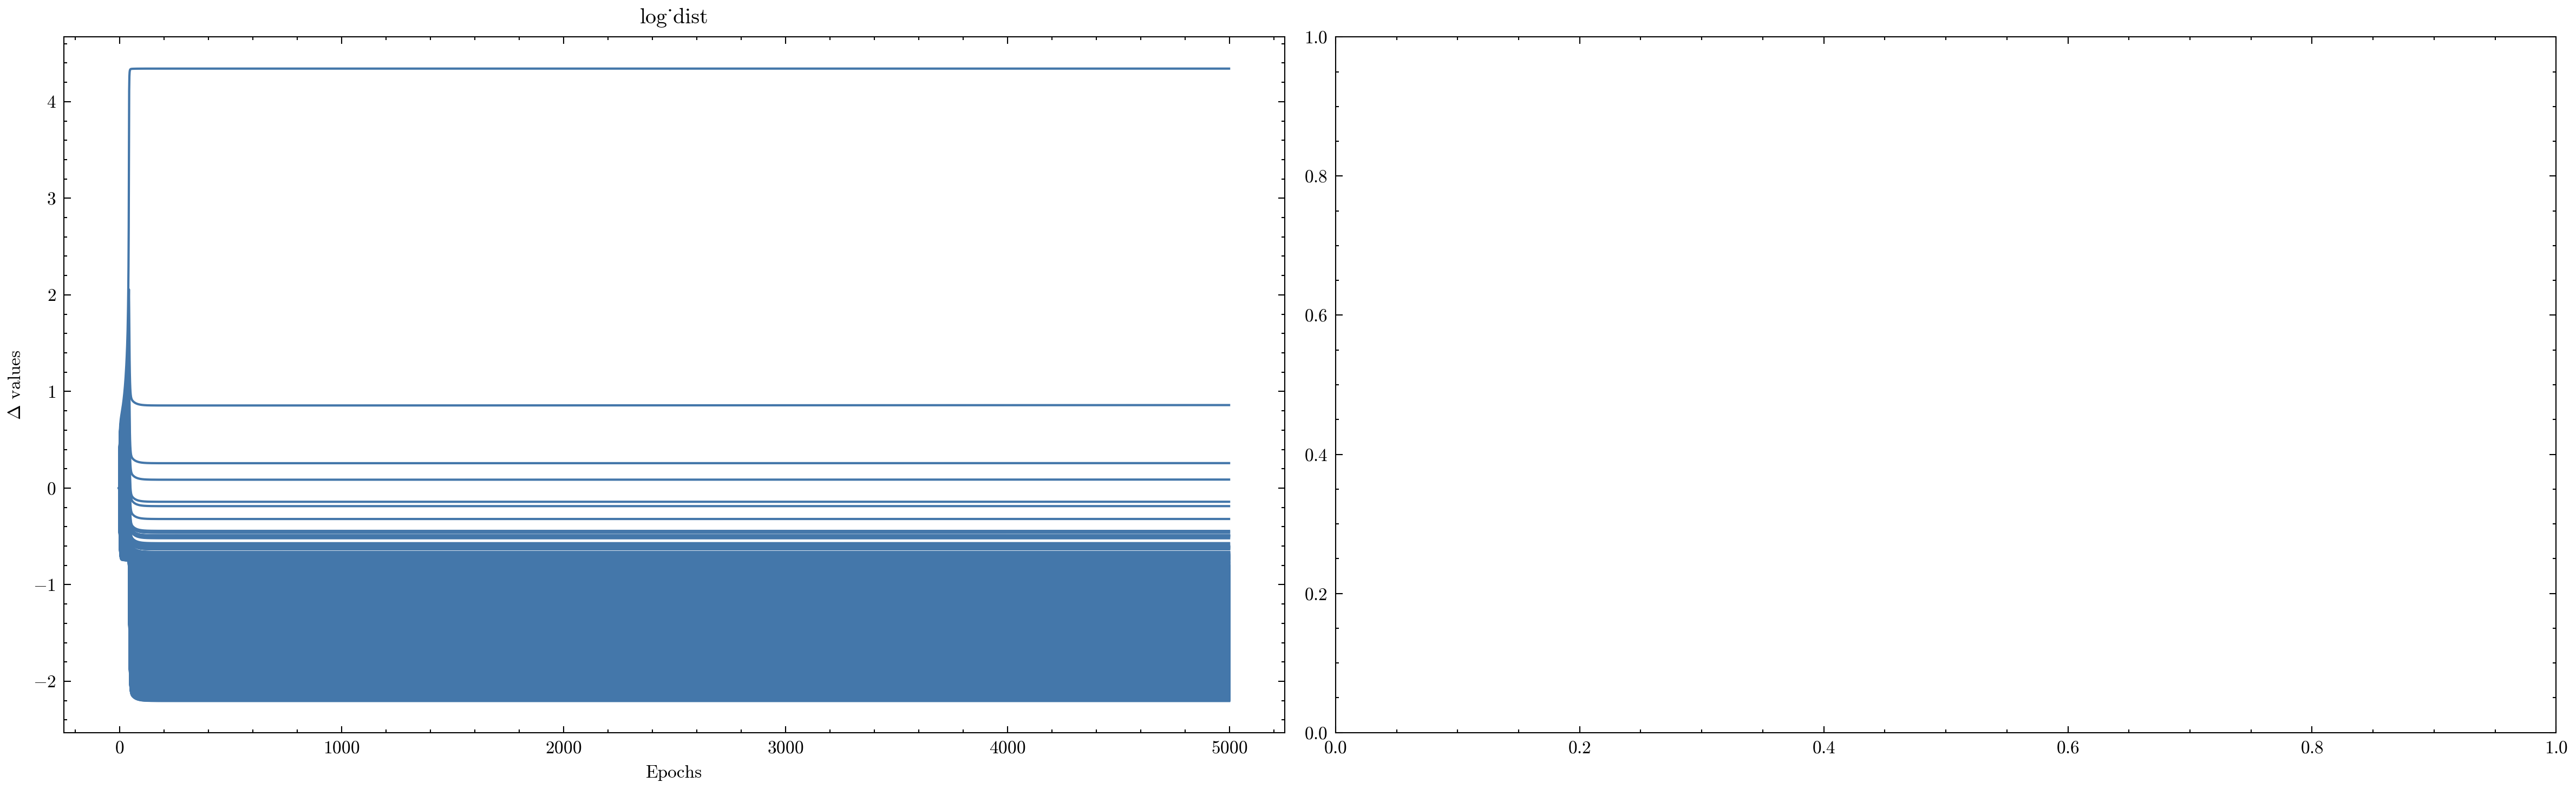

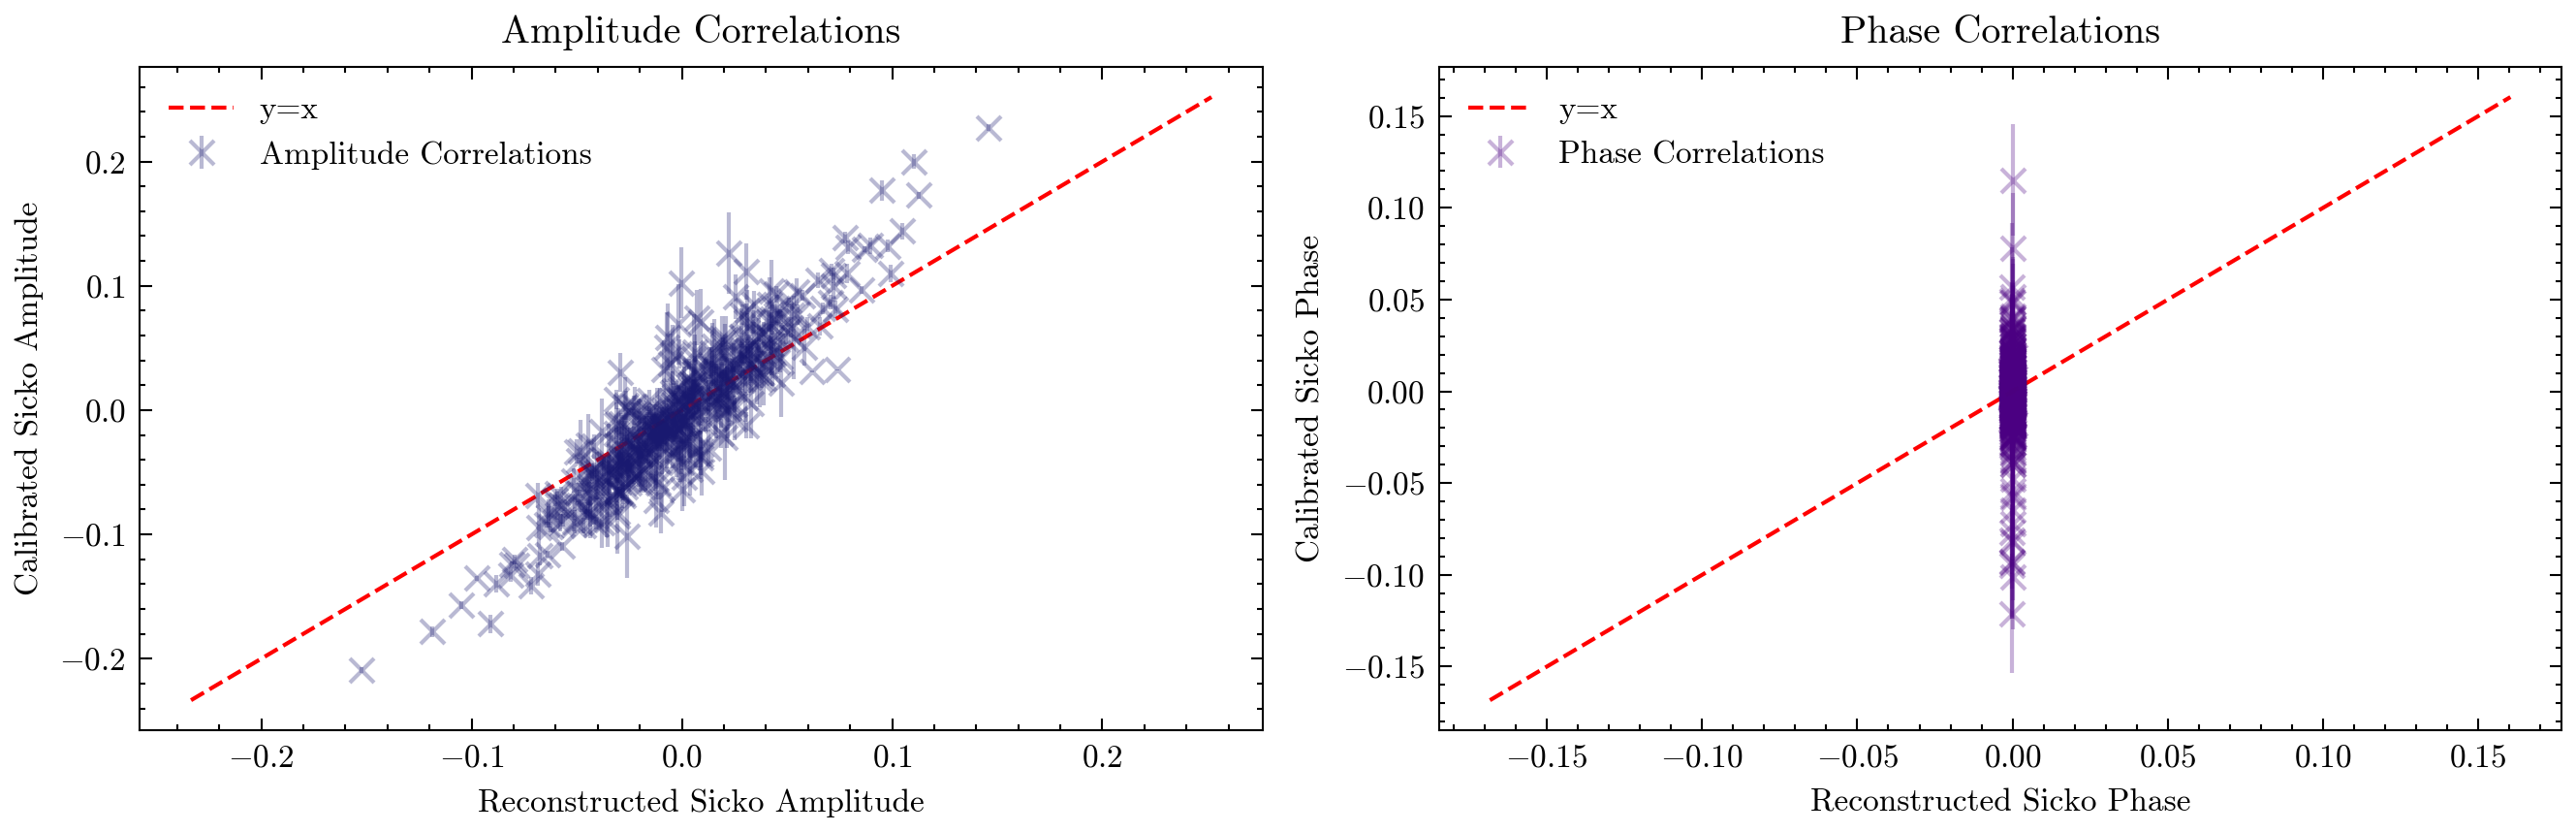

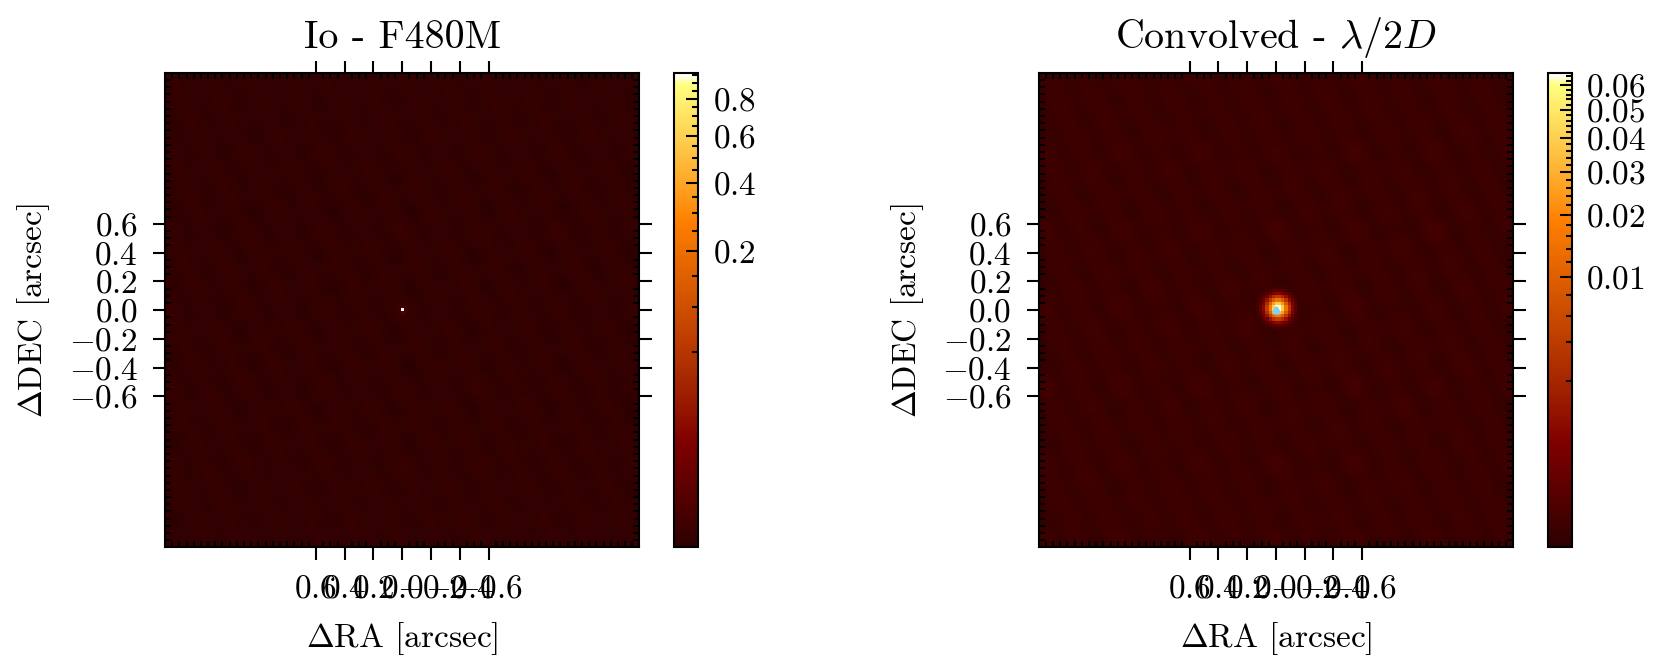

In [126]:
print(phase_centre(result.model, ois[0], args))
print(prior_data_balance(result.model, ois[0], args))


amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)


for oi in ois:
    dist = 10 ** result.model.params["log_dist"][oi.get_key("log_dist")]

    # dist = dist.at[dist.shape[0] // 2, dist.shape[1] // 2].set(0.00)

    sicko_amp, sicko_phase = oi(result.model)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        sicko_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Sicko Amplitude")
    ax[0].set_ylabel("Calibrated Sicko Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        sicko_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Sicko Phase")
    ax[1].set_ylabel("Calibrated Sicko Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.6, -0.4, -0.2, 0.0, 0.2, 0.4, 0.6]

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax[0],
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        power=0.3,
        vmin=None,
        ticks=ticks,
    )
    # ax[0].scatter([0], [0], marker="^", color="skyblue", s=1)

    c1 = dorito.plotting.plot_result(
        ax[1],
        blur_distribution(dist, model, oi, factor=0.5),
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        power=0.3,
        vmin=None,
        ticks=ticks,
    )
    ax[1].scatter([0], [0], marker="^", color="skyblue", s=1)
    fig.colorbar(c1, ax=ax[1])

    fig.colorbar(c0)
    # pa = model.params["position_angles"][exp.key]
    ax[0].set_title(
        f"Io - {oi.filter}"  # - {model.params['position_angles'][exp.get_key('position_angles')]:.1f}deg"
    )
    ax[1].set(title=r"Convolved - $\lambda / 2D$")

    plt.tight_layout()
    # plt.savefig(output_path + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

In [127]:
bfgs_model = BFGS_logdist(
    model=result.model, exposures=ois, reg_args=args, max_steps=2**16
)

Initial loss: 22752.35142376779
Final loss: 2481.5356439494803
7746 2695




In [128]:
print(bfgs_model.get_distribution(ois[0]).sum())
print(phase_centre(bfgs_model, ois[0]))

1.000003803096859
0.046811836319067095


In [129]:
# np.save("files/71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "121pix_os8.npy", bfgs_model.params, allow_pickle=True)

# params = np.load(output_path + "121pix_os8.npy", allow_pickle=True).item()
# bfgs_model = model.set("params", params)

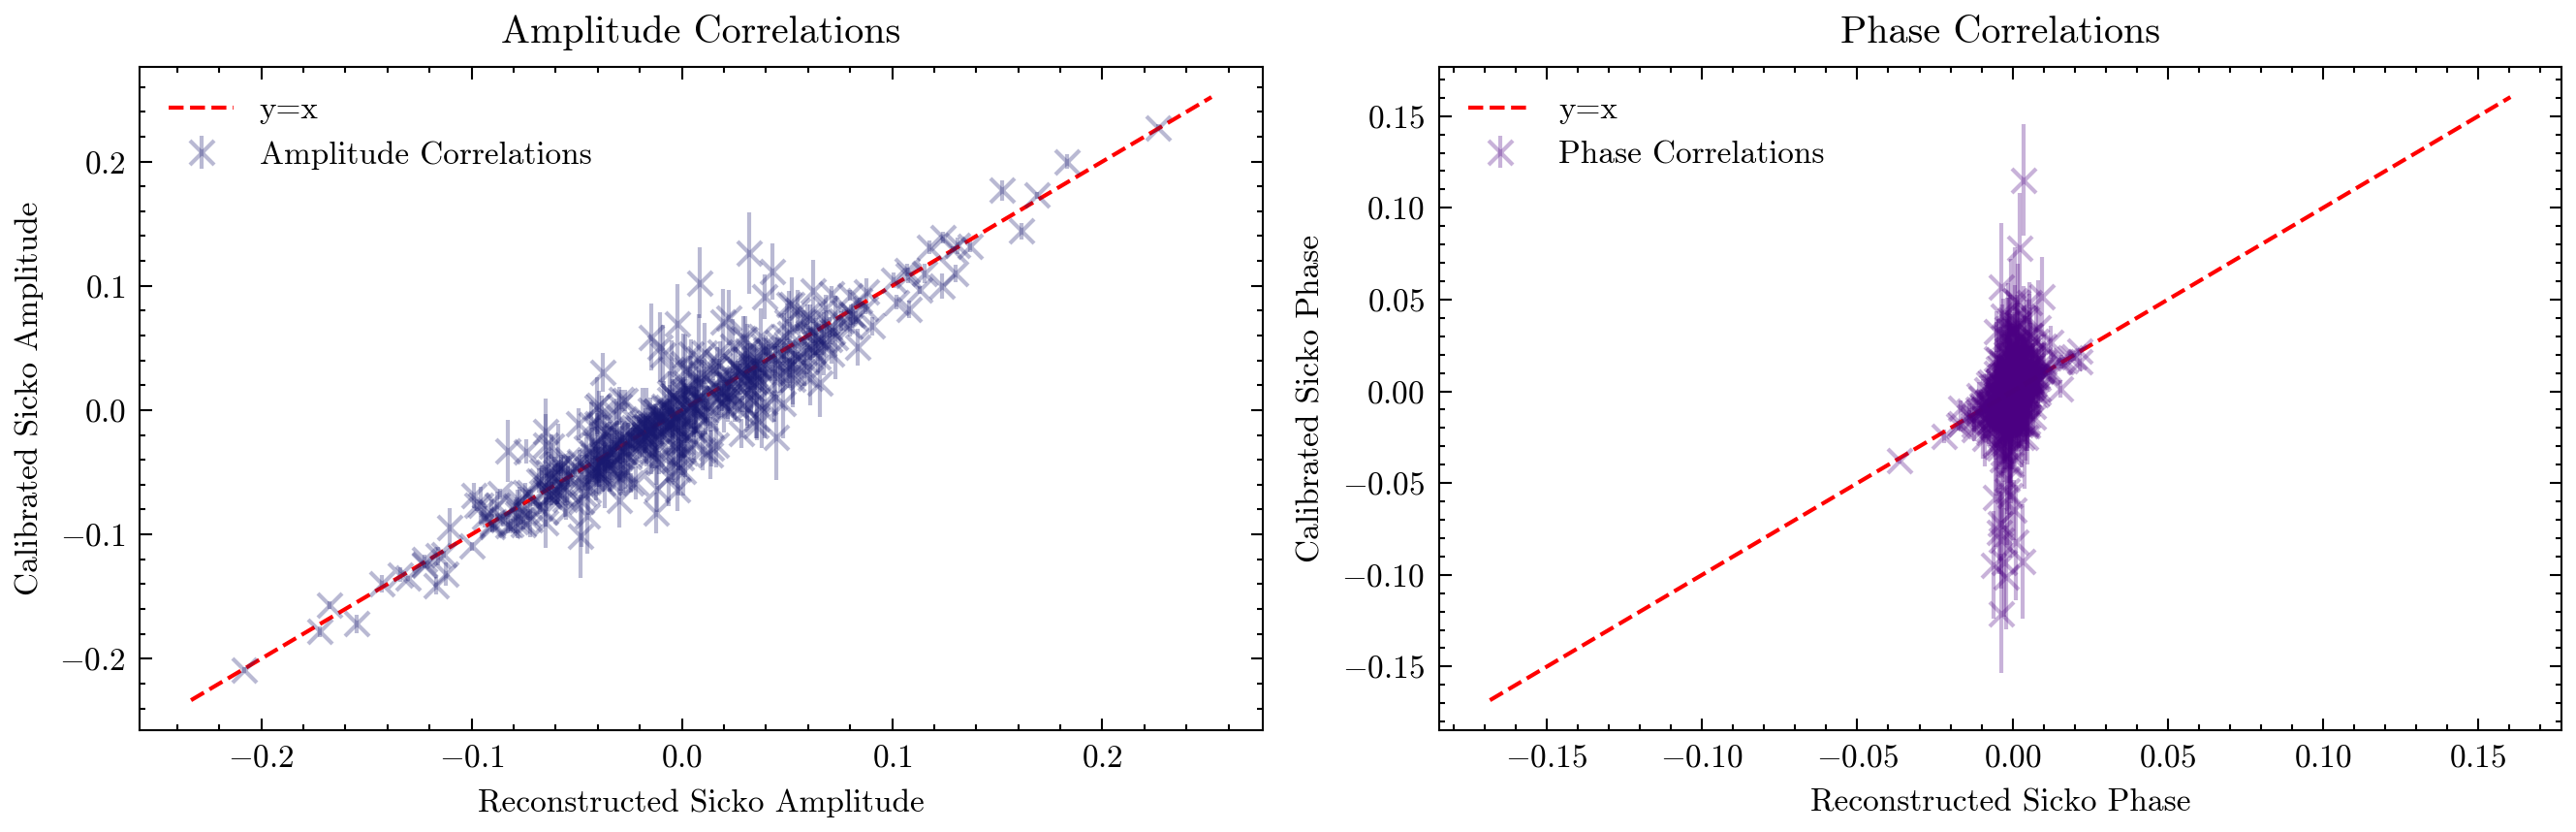

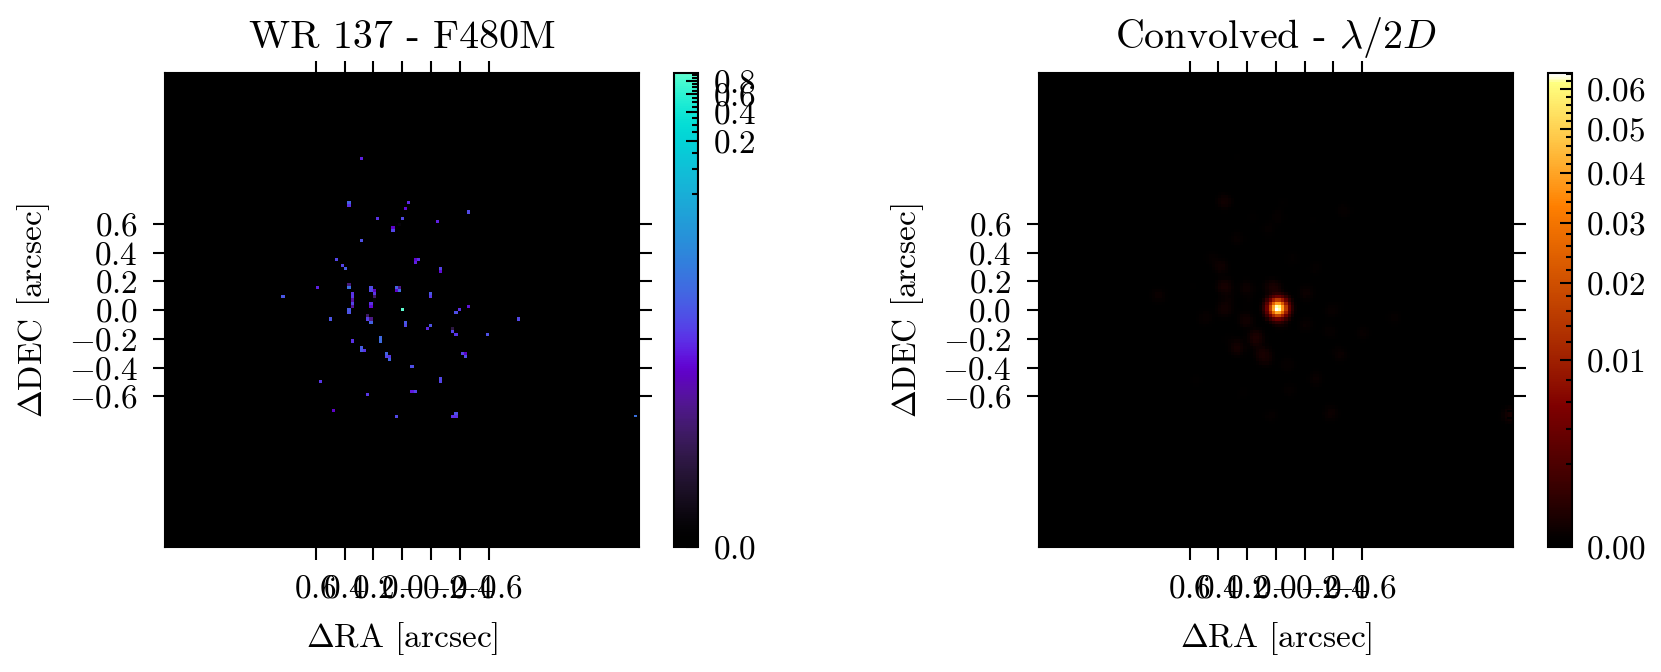

1.000003803096859


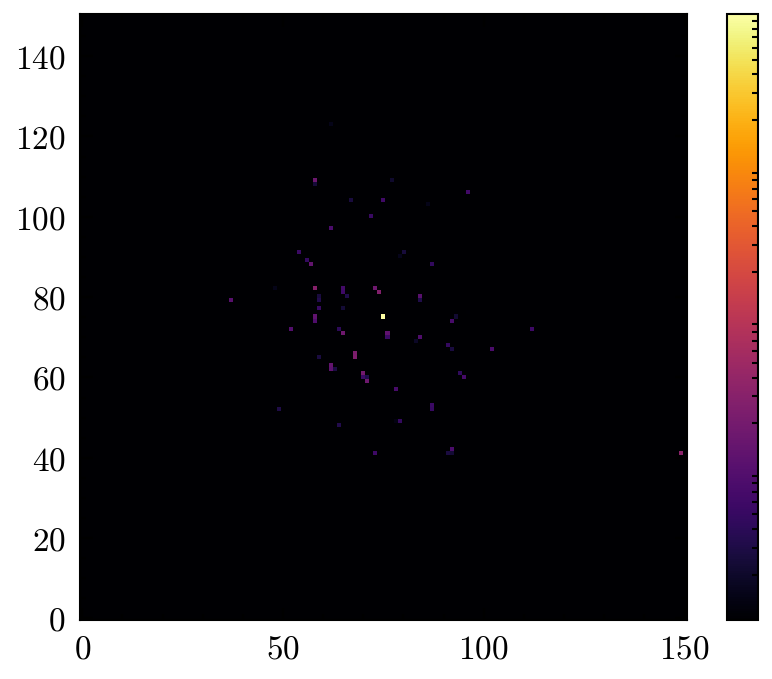

In [131]:
for oi in ois:
    dist = 10 ** bfgs_model.params["log_dist"][oi.get_key("log_dist")]

    sicko_amp, sicko_phase = oi(bfgs_model)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        sicko_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Sicko Amplitude")
    ax[0].set_ylabel("Calibrated Sicko Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        sicko_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Sicko Phase")
    ax[1].set_ylabel("Calibrated Sicko Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6]

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax[0],
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        # cmap="afmhot_u",
        cmap="cmr.cosmic",
        power=0.1,
        vmin=0,
        ticks=ticks,
    )

    c1 = dorito.plotting.plot_result(
        ax[1],
        blur_distribution(dist, model, oi, factor=0.5),
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_u",
        power=0.5,
        vmin=None,
        ticks=ticks,
    )
    fig.colorbar(c1, ax=ax[1])

    fig.colorbar(c0)
    # pa = model.params["position_angles"][exp.key]
    ax[0].set_title(
        f"WR 137 - {oi.filter}"  # - {model.params['position_angles'][exp.get_key('position_angles')]:.1f}deg"
    )
    ax[1].set(title=r"Convolved - $\lambda / 2D$")

    plt.tight_layout()
    # plt.savefig(output_path + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

    print(dist.sum())

    rl_dist = np.clip(dist + 1e-16)
    rl_dist = rl_dist / rl_dist.max()
    plt.imshow(rl_dist, norm=mpl.colors.LogNorm(vmin=1e-4, vmax=1.0))
    plt.colorbar(ticks=[])
    plt.show()

In [17]:
params = bfgs_model.params
for oi in ois:
    dist = 10 ** params["log_dist"][oi.get_key("log_dist")]
    blurred_dist = blur_distribution(dist, bfgs_model, oi, factor=0.01)
    params["log_dist"][oi.get_key("log_dist")] = np.log10(
        blurred_dist / blurred_dist.sum()
    )

reg_model = bfgs_model.set("params", params)

In [18]:
n_epoch = 15000

config = {
    # "log_dist": sgd(5e-8, 0, (500, 0.5)),
    # "log_dist": sgd(3e-800, 0),
    "log_dist": sgd(1e-8, 0),
    # "log_dist": sgd(1e-8, 0, (100, 10), (2000, 0.5)),
    # "log_dist": adam(1e-2, 0, (500, 2)),
    # "log_dist": sgd(5e-9, 0, (500, 2), (1000, 2)),
    # "log_dist": sgd(1e-8, 0, (10, 5), (500, 0.25), (1000, 1.5), (1300, 0.75)),
}

args = {
    "reg_func_dict": {
        "ME": dorito.stats.ME,
        "TV": dorito.stats.TV,
        "L2": dorito.stats.L2,
        "TSV": dorito.stats.TSV,
    },
    "reg_dict": {
        # "ME": 5e5,
        # "TV": 1.0,
        # "L2": 1e-5,
        # "TSV": 1e12,
        "TSV": 5e6,
    },
}

trainer = amigo.fitting.Trainer(
    loss_fn=regularised_loss_fn,
    cache=fisher_cache,
    # grad_fn=grad_fn,
    norm_fn=normalise_distribution,
    looper_fn=looper,
)

trainer = trainer.update_fishers(
    model=reg_model,
    exposures=[],
    parameters=[],
)

# Train the model
result = trainer.train(
    model=reg_model,
    optimisers=config,
    epochs=n_epoch,
    batches=ois,
    args=args,
    # batches=exposures,
)

0it [00:00, ?it/s]

  0%|          | 0/15000 [00:00<?, ?it/s]

Invalid nan value encountered in the output of a jax.jit function. Calling the de-optimized version.


FloatingPointError: invalid value (nan) encountered in mul

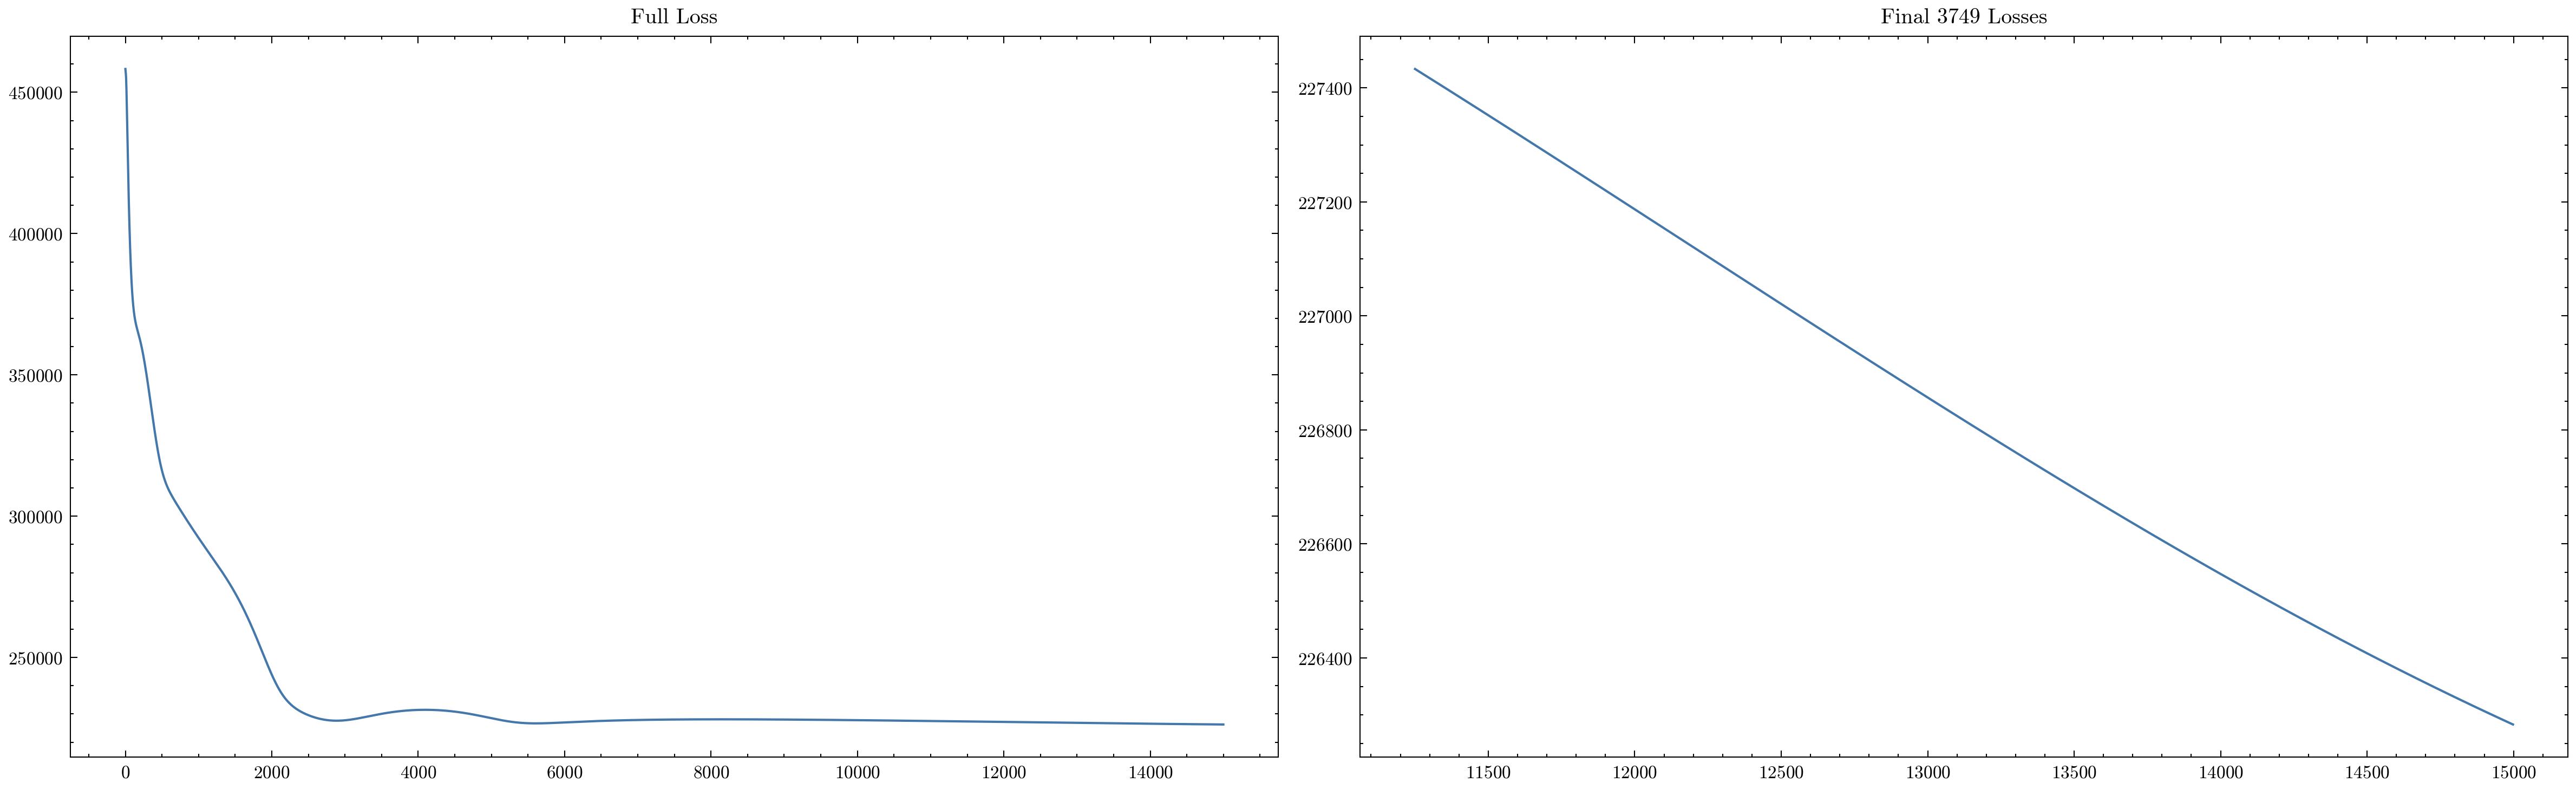

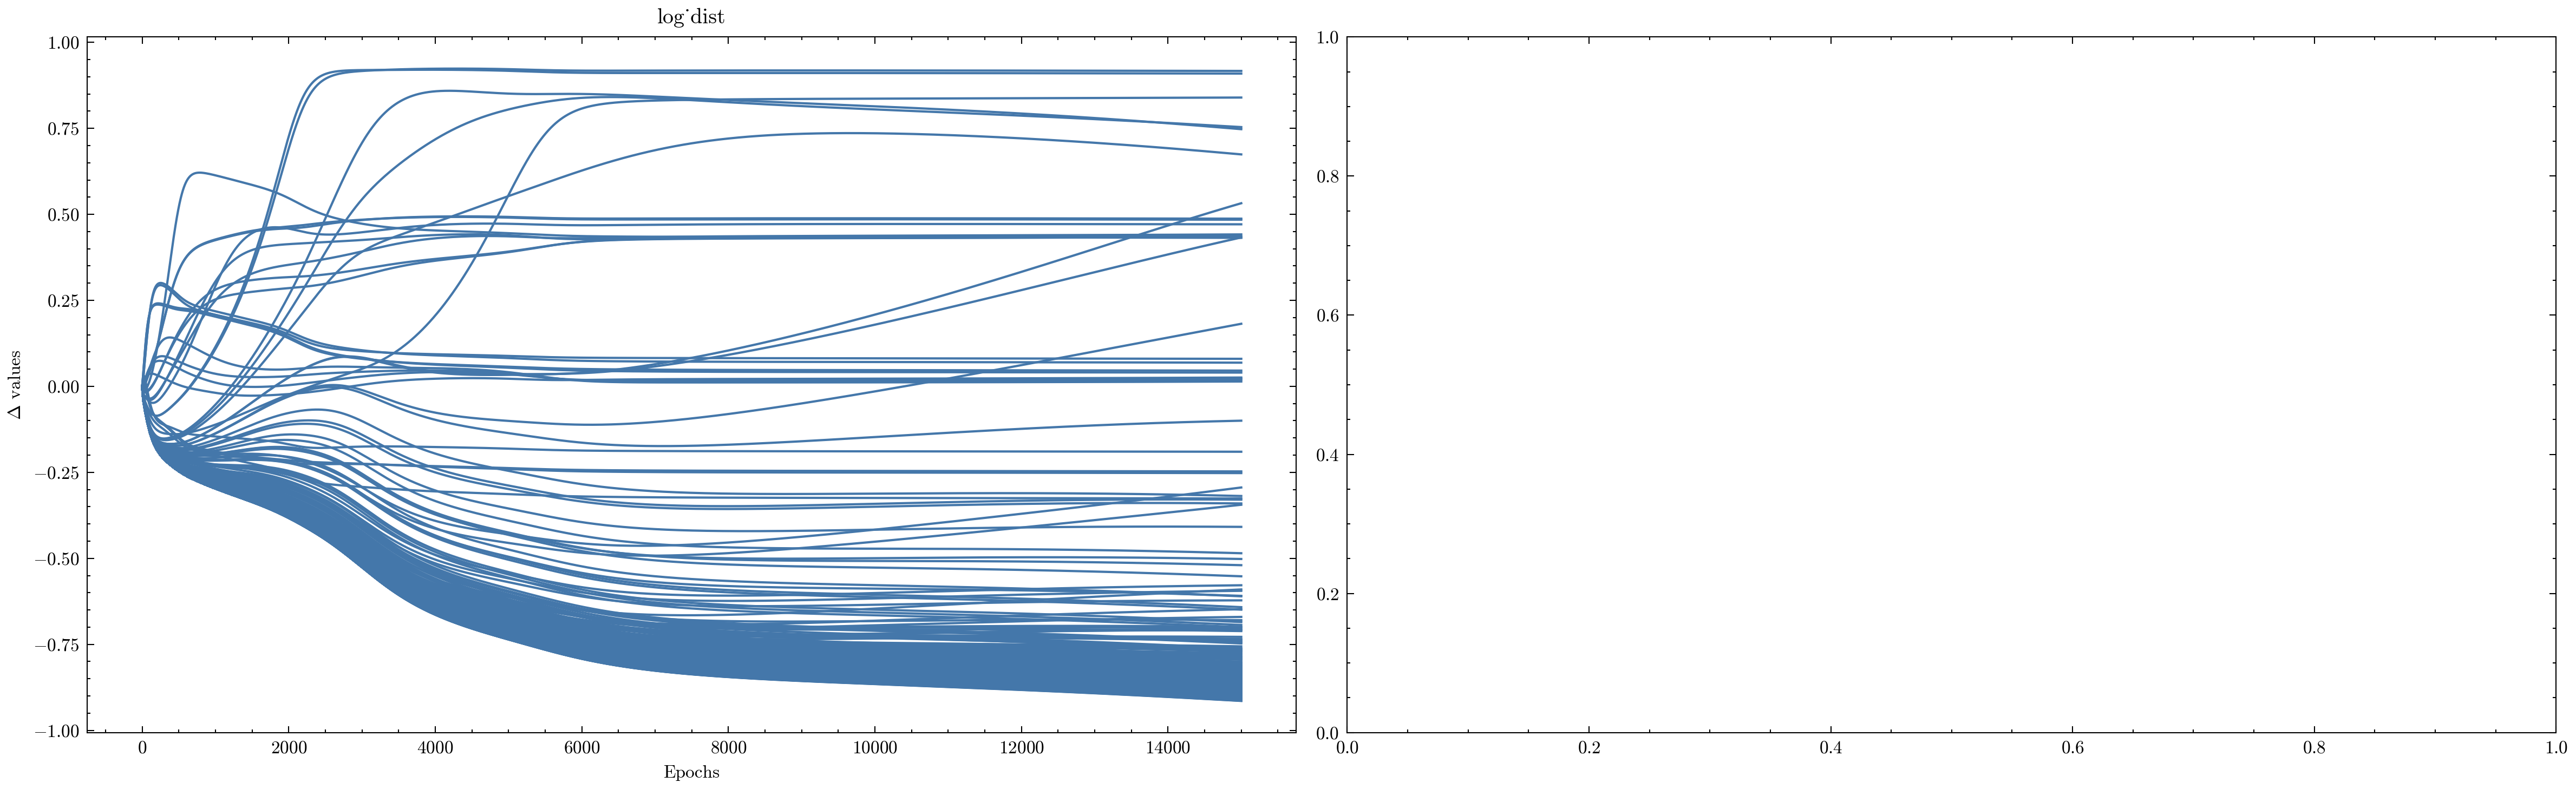

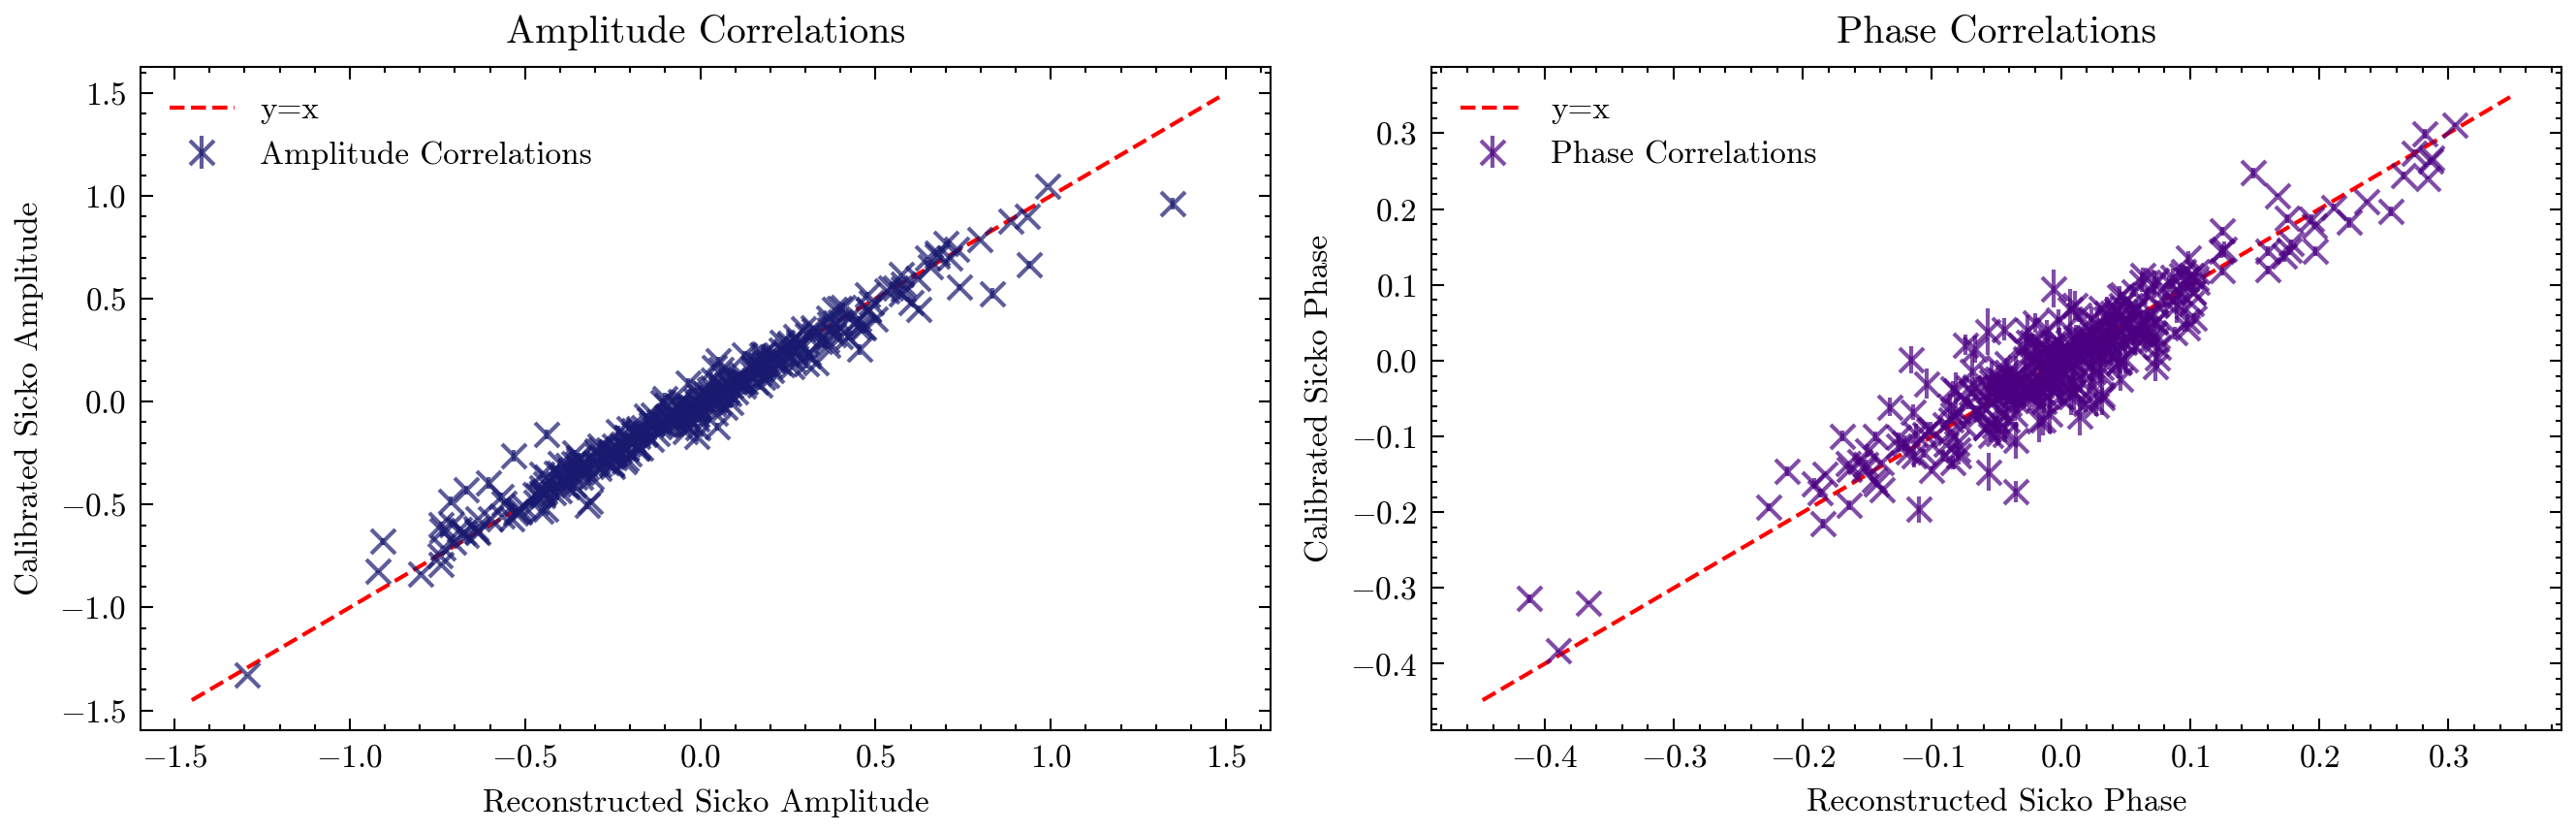

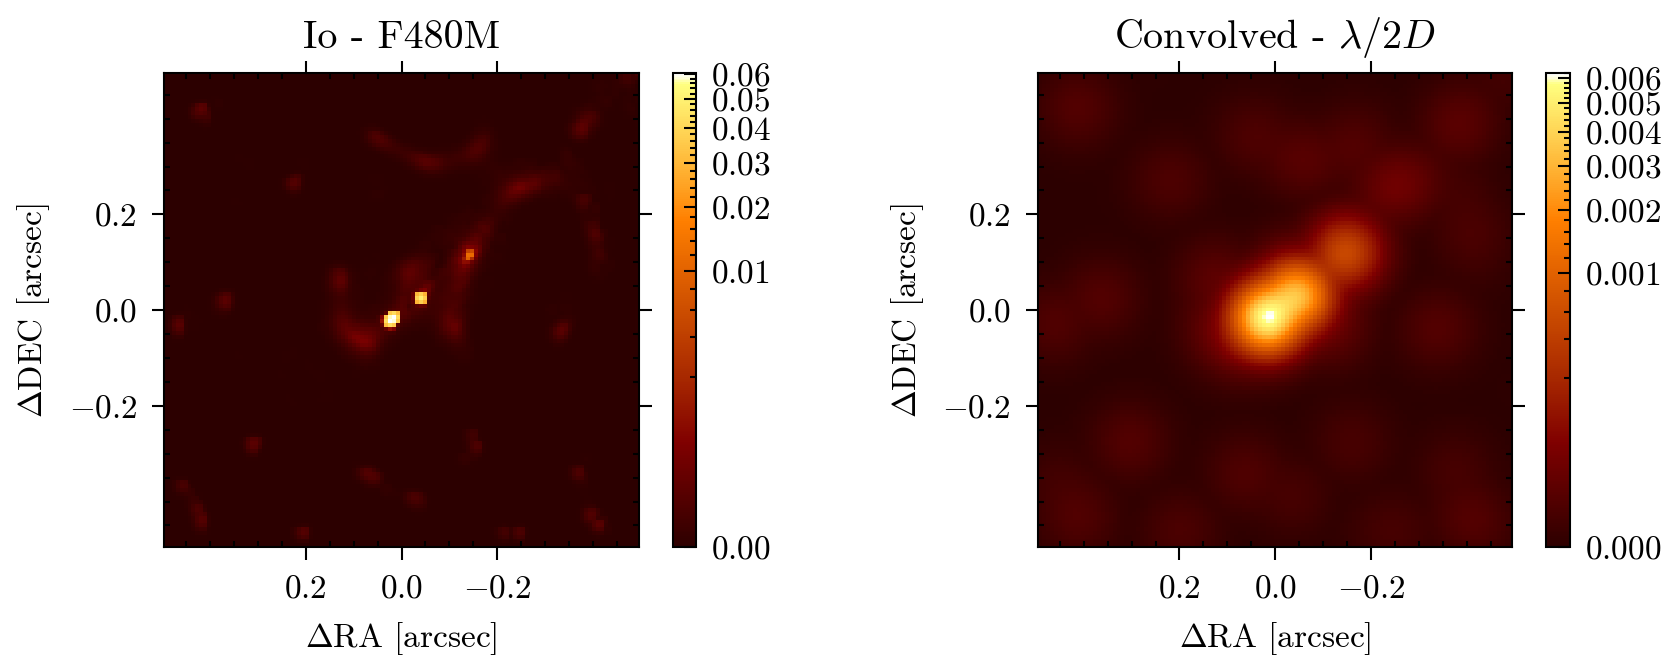

In [ ]:
amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

for oi in ois:
    dist = 10 ** result.model.params["log_dist"][oi.get_key("log_dist")]

    sicko_amp, sicko_phase = oi(result.model)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        sicko_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.7,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Sicko Amplitude")
    ax[0].set_ylabel("Calibrated Sicko Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        sicko_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.7,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Sicko Phase")
    ax[1].set_ylabel("Calibrated Sicko Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.2, 0, 0.2]

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax[0],
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        power=0.3,
        vmin=0,
        ticks=ticks,
    )

    c1 = dorito.plotting.plot_result(
        ax[1],
        blur_distribution(dist, model, oi, factor=0.5),
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        power=0.3,
        vmin=None,
        ticks=ticks,
    )
    fig.colorbar(c1, ax=ax[1])

    fig.colorbar(c0)
    # pa = model.params["position_angles"][exp.key]
    ax[0].set_title(
        f"Io - {oi.filter}"  # - {model.params['position_angles'][exp.get_key('position_angles')]:.1f}deg"
    )
    ax[1].set(title=r"Convolved - $\lambda / 2D$")

    plt.tight_layout()
    # plt.savefig(output_path + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

In [ ]:
last_model = BFGS_logdist(
    model=result.model,
    exposures=ois,
    reg_args=args,
    max_steps=2**16,
)

Initial loss: 226282.70181366627


E0514 15:47:42.703019 2159313 pjrt_stream_executor_client.cc:2839] Execution of replica 0 failed: INTERNAL: CpuCallback error calling callback: Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 205, in start
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/asyncio/base_events.py", line 608, in run_forever
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once
  File "/me

EquinoxRuntimeError: Above is the stack outside of JIT. Below is the stack inside of JIT:
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/optimistix/_minimise.py", line 107, in minimise
    return iterative_solve(
           ^^^^^^^^^^^^^^^^
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/optimistix/_iterate.py", line 351, in iterative_solve
    sol = result.error_if(sol, result != RESULTS.successful)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
equinox.EquinoxRuntimeError: The maximum number of steps was reached in the nonlinear solver. The problem may not be solveable (e.g., a root-find on a function that has no roots), or you may need to increase `max_steps`.

-------------------

An error occurred during the runtime of your JAX program.

1) Setting the environment variable `EQX_ON_ERROR=breakpoint` is usually the most useful
way to debug such errors. This can be interacted with using most of the usual commands
for the 